# Dissertation Results — Reference Notebook

Notebook de referencia unica para a dissertacao. Carrega os checkpoints dos experimentos
executados no Google Colab e gera todas as tabelas e figuras usadas no texto.

**Fontes de dados (em `data/`):**
- `benchmark_progress.pkl` — Resultados do benchmark em 4 datasets reais (dados crus), do `Benchmark_Real_Datasets_Colab.ipynb`
- `ablation_retweet_norm_progress.pkl` — Resultados da ablacao retweet normalizado, do `Ablation_Retweet_Norm_Colab.ipynb`
- `benchmark_checkpoints.zip` — Checkpoints e logs de treino do benchmark (contem curvas de convergencia)
- `benchmark_checkpoints_old.zip` — Checkpoints da 1a rodada do benchmark (stackoverflow + amazon)
- `hardware_info.json` — Info do ambiente Colab

**Datasets:** Amazon, Stackoverflow, Taxi, Retweet (cru e normalizado)
**Modelos:** THP, RoTHP, HoTHP
**Protocolo:** 3 seeds (2019, 2020, 2021), 100 epocas, avaliacao em 1x e 5x (extrapolacao)

In [148]:
import pickle, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

# ── Configuracao global de plots ──
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.1,
})

# Diretorio de saida para figuras da dissertacao
FIG_DIR = "./figuras_dissertacao"
os.makedirs(FIG_DIR, exist_ok=True)

print("Imports OK")

Imports OK


In [149]:
# ── Carregar dados ────────────────────────────────────────────────────

DATA_DIR = "./data"

# Benchmark em dados crus (4 datasets)
with open(os.path.join(DATA_DIR, "benchmark_progress.pkl"), "rb") as f:
    bench_raw = pickle.load(f)

# Ablacao retweet normalizado
with open(os.path.join(DATA_DIR, "ablation_retweet_norm_progress.pkl"), "rb") as f:
    ablation = pickle.load(f)

# Hardware info
with open(os.path.join(DATA_DIR, "hardware_info.json")) as f:
    hardware = json.load(f)

df_bench = pd.DataFrame(bench_raw["results"])
df_ablation = pd.DataFrame(ablation["results"])

print(f"Benchmark: {len(df_bench)} resultados, datasets={df_bench['dataset'].unique().tolist()}")
print(f"Ablacao:   {len(df_ablation)} resultados, datasets={df_ablation['dataset'].unique().tolist()}")
print(f"Hardware:  {hardware['gpu_name']}, {hardware['gpu_vram_gb']}GB VRAM")

Benchmark: 60 resultados, datasets=['stackoverflow', 'amazon', 'taxi', 'retweet']
Ablacao:   12 resultados, datasets=['retweet_norm']
Hardware:  NVIDIA A100-SXM4-80GB, 79.25GB VRAM


In [150]:
# ── DataFrame unificado ───────────────────────────────────────────────
# Junta benchmark (dados crus) e ablacao (retweet normalizado) num unico DF
# com coluna 'condition' para distinguir

df_bench["condition"] = "raw"
df_ablation["condition"] = "normalized"

# Renomeia dataset da ablacao para ficar claro
df_ablation_copy = df_ablation.copy()
df_ablation_copy["dataset"] = "retweet"  # mesmo dataset, condicao diferente

df_all = pd.concat([df_bench, df_ablation_copy], ignore_index=True)

# Tempos de treino
train_times_bench = bench_raw.get("train_times", {})
train_times_ablation = ablation.get("train_times", {})

print(f"Total: {len(df_all)} resultados")
df_all.head()

Total: 72 resultados


,dataset,model,seed,extrap,max_len,nll,acc,rmse,condition
0,stackoverflow,THP,2019,1x,20,2.735510,0.476178,1.730325,raw
1,stackoverflow,THP,2019,5x,100,2.508991,0.452096,1.405623,raw
2,stackoverflow,THP,2020,1x,20,2.759745,0.470928,1.767629,raw
3,stackoverflow,THP,2020,5x,100,2.548909,0.447413,1.417268,raw
4,stackoverflow,THP,2021,1x,20,2.738337,0.476178,1.761277,raw


---
## 1. Tabela de Resultados — Dados Reais (Tabela principal da dissertacao)

Corresponde a `\ref{tab:resultados-reais}` no capitulo de Resultados.
Datasets: Amazon, Stackoverflow, Taxi, Retweet. Modelos: THP, RoTHP, HoTHP.
Condicao: dados crus (raw), 3 seeds, 100 epocas.

In [151]:
# ── Funcoes auxiliares para tabelas ───────────────────────────────────

def summarize(df, dataset, model, condition="raw"):
    """Retorna dict com media e std de NLL, Acc, RMSE para 1x e 5x."""
    sub = df[(df["dataset"] == dataset) & (df["model"] == model) & (df["condition"] == condition)]
    out = {}
    for ext in ["1x", "5x"]:
        s = sub[sub["extrap"] == ext]
        if len(s) == 0:
            out[ext] = {"nll": (np.nan, np.nan), "acc": (np.nan, np.nan), "rmse": (np.nan, np.nan)}
        else:
            out[ext] = {
                "nll":  (s["nll"].mean(),  s["nll"].std()),
                "acc":  (s["acc"].mean(),  s["acc"].std()),
                "rmse": (s["rmse"].mean(), s["rmse"].std()),
            }
    # delta NLL
    if not np.isnan(out["1x"]["nll"][0]) and not np.isnan(out["5x"]["nll"][0]):
        out["delta_nll"] = out["5x"]["nll"][0] - out["1x"]["nll"][0]
    else:
        out["delta_nll"] = np.nan
    return out


def fmt_pm(mean, std, decimals=3):
    """Formata como 'mean +/- std'."""
    if np.isnan(mean):
        return "---"
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"


def fmt_pm_latex(mean, std, decimals=3, bold=False):
    """Formata para LaTeX como '$mean \\pm std$'."""
    if np.isnan(mean):
        return "---"
    # Formata com virgula decimal (pt-BR)
    m = f"{mean:.{decimals}f}".replace(".", "{,}")
    s = f"{std:.{decimals}f}".replace(".", "{,}")
    txt = f"${m} \\pm {s}$"
    if bold:
        txt = f"$\\mathbf{{{m} \\pm {s}}}$"
    return txt

print("Funcoes auxiliares definidas.")

Funcoes auxiliares definidas.


In [152]:
# ── Tabela 1: Resultados por seed (detalhada) ────────────────────────

DATASETS_ORDER = ["amazon", "stackoverflow", "taxi", "retweet"]
MODELS_PER_DS = {
    "amazon":        ["THP", "RoTHP", "HoTHP"],
    "stackoverflow": ["THP", "RoTHP", "HoTHP"],
    "taxi":          ["RoTHP", "HoTHP"],
    "retweet":       ["RoTHP", "HoTHP"],
}
SEEDS = [2019, 2020, 2021]

print(f"{'Dataset':<15} {'Model':<8} {'Seed':>5}  {'NLL 1x':>10} {'NLL 5x':>14} "
      f"{'Acc 1x':>8} {'Acc 5x':>8} {'RMSE 1x':>10} {'RMSE 5x':>10}")
print("=" * 100)

for ds in DATASETS_ORDER:
    models = MODELS_PER_DS[ds]
    for model in models:
        for seed in SEEDS:
            sub = df_bench[(df_bench["dataset"] == ds) & (df_bench["model"] == model) & (df_bench["seed"] == seed)]
            r1 = sub[sub["extrap"] == "1x"]
            r5 = sub[sub["extrap"] == "5x"]

            n1 = f"{r1['nll'].values[0]:.4f}" if len(r1) else "---"
            n5 = f"{r5['nll'].values[0]:.4f}" if len(r5) else "---"
            a1 = f"{r1['acc'].values[0]:.4f}" if len(r1) else "---"
            a5 = f"{r5['acc'].values[0]:.4f}" if len(r5) else "---"
            rm1 = f"{r1['rmse'].values[0]:.4f}" if len(r1) else "---"
            rm5 = f"{r5['rmse'].values[0]:.4f}" if len(r5) else "---"

            ds_label = ds if seed == SEEDS[0] and model == models[0] else ""
            print(f"{ds_label:<15} {model:<8} {seed:>5}  {n1:>10} {n5:>14} "
                  f"{a1:>8} {a5:>8} {rm1:>10} {rm5:>10}")
        print()
    print("-" * 100)

Dataset         Model     Seed      NLL 1x         NLL 5x   Acc 1x   Acc 5x    RMSE 1x    RMSE 5x
amazon          THP       2019      2.2768         2.2496   0.3078   0.3175     0.4852     0.4878
                THP       2020      2.2718         2.2336   0.3087   0.3270     0.4913     0.4913
                THP       2021      2.2737         2.2478   0.3162   0.3216     0.4915     0.4950

                RoTHP     2019      2.2769         2.2545   0.3090   0.3221     0.4926     0.4903
                RoTHP     2020      2.2723         2.2513   0.3072   0.3149     0.4876     0.4828
                RoTHP     2021      2.2679         2.2503   0.3139   0.3254     0.4866     0.4826

                HoTHP     2019      2.2714         2.1959   0.3108   0.3403     0.4889     0.4855
                HoTHP     2020      2.2676         2.1930   0.3087   0.3365     0.4875     0.4806
                HoTHP     2021      2.2654         2.1920   0.3123   0.3424     0.4888     0.4821

-----------------

In [153]:
# ── Tabela 2: Media +/- Std (para dissertacao) ───────────────────────

print("=" * 95)
print("TABELA PARA DISSERTACAO — Dados Reais (media ± std, 3 seeds)")
print("=" * 95)
print(f"{'Dataset':<15} {'Model':<8} {'NLL 1x':>18} {'NLL 5x':>18} {'dNLL':>10} {'Acc 5x':>18}")
print("-" * 95)

for ds in DATASETS_ORDER:
    models = MODELS_PER_DS[ds]
    for model in models:
        s = summarize(df_all, ds, model, "raw")
        n1 = fmt_pm(*s["1x"]["nll"])
        n5 = fmt_pm(*s["5x"]["nll"])
        a5 = fmt_pm(*s["5x"]["acc"])
        dn = f"{s['delta_nll']:+.3f}" if not np.isnan(s["delta_nll"]) else "---"

        ds_label = ds if model == models[0] else ""
        print(f"{ds_label:<15} {model:<8} {n1:>18} {n5:>18} {dn:>10} {a5:>18}")
    print()

TABELA PARA DISSERTACAO — Dados Reais (media ± std, 3 seeds)
Dataset         Model                NLL 1x             NLL 5x       dNLL             Acc 5x
-----------------------------------------------------------------------------------------------
amazon          THP           2.274 ± 0.003      2.244 ± 0.009     -0.030      0.322 ± 0.005
                RoTHP         2.272 ± 0.004      2.252 ± 0.002     -0.020      0.321 ± 0.005
                HoTHP         2.268 ± 0.003      2.194 ± 0.002     -0.074      0.340 ± 0.003

stackoverflow   THP           2.745 ± 0.013      2.521 ± 0.024     -0.224      0.451 ± 0.003
                RoTHP         2.753 ± 0.006      2.538 ± 0.004     -0.215      0.450 ± 0.000
                HoTHP         2.742 ± 0.025      2.530 ± 0.029     -0.212      0.451 ± 0.003

taxi            RoTHP        -0.269 ± 0.006     -0.176 ± 0.050     +0.092      0.907 ± 0.002
                HoTHP        -0.271 ± 0.007     -0.212 ± 0.011     +0.059      0.907 ± 0.004

ret

In [154]:
# ── Tabela LaTeX: tab:resultados-reais ────────────────────────────────
# Gera o codigo LaTeX pronto para copiar na dissertacao

def find_best_nll_5x(ds, models):
    """Retorna o modelo com menor NLL media em 5x."""
    best_model, best_nll = None, np.inf
    for m in models:
        s = summarize(df_all, ds, m, "raw")
        nll_mean = s["5x"]["nll"][0]
        if not np.isnan(nll_mean) and nll_mean < best_nll:
            best_nll = nll_mean
            best_model = m
    return best_model

print(r"""\begin{table}[h!]
\centering
\caption{NLL nos datasets reais (média $\pm$ desvio padrão, 3 sementes). $\Delta$NLL é a diferença $5\times$ menos $1\times$: valores negativos indicam que o modelo melhora com sequências mais longas. Valores menores de NLL são melhores. O melhor resultado para cada dataset e condição está em negrito.}
\label{tab:resultados-reais}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llcccc}
\toprule
Dataset & Modelo & NLL $1\times$ & NLL $5\times$ & $\Delta$NLL & Acc $5\times$ \\
\midrule""")

for ds in DATASETS_ORDER:
    models = MODELS_PER_DS[ds]
    best_5x = find_best_nll_5x(ds, models)
    n_models = len(models)

    for i, model in enumerate(models):
        s = summarize(df_all, ds, model, "raw")
        is_best = (model == best_5x)

        n1 = fmt_pm_latex(*s["1x"]["nll"])
        n5 = fmt_pm_latex(*s["5x"]["nll"], bold=is_best)
        a5 = fmt_pm_latex(*s["5x"]["acc"], bold=is_best)

        # delta NLL
        if not np.isnan(s["delta_nll"]):
            dn_val = s["delta_nll"]
            if abs(dn_val) > 1000:
                dn = "---"
            else:
                dn_str = f"{dn_val:+.3f}".replace(".", "{,}")
                if is_best:
                    dn = f"$\\mathbf{{{dn_str}}}$"
                else:
                    dn = f"${dn_str}$"
        else:
            dn = "---"

        prefix = f"\\multirow{{{n_models}}}{{*}}{{{ds.capitalize()}}}" if i == 0 else "    "
        print(f"    {prefix} & {model} & {n1} & {n5} & {dn} & {a5} \\\\")

    if ds != DATASETS_ORDER[-1]:
        print(r"\midrule")

print(r"""\bottomrule
\end{tabular}
}
\end{table}""")

\begin{table}[h!]
\centering
\caption{NLL nos datasets reais (média $\pm$ desvio padrão, 3 sementes). $\Delta$NLL é a diferença $5\times$ menos $1\times$: valores negativos indicam que o modelo melhora com sequências mais longas. Valores menores de NLL são melhores. O melhor resultado para cada dataset e condição está em negrito.}
\label{tab:resultados-reais}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llcccc}
\toprule
Dataset & Modelo & NLL $1\times$ & NLL $5\times$ & $\Delta$NLL & Acc $5\times$ \\
\midrule
    \multirow{3}{*}{Amazon} & THP & $2{,}274 \pm 0{,}003$ & $2{,}244 \pm 0{,}009$ & $-0{,}030$ & $0{,}322 \pm 0{,}005$ \\
         & RoTHP & $2{,}272 \pm 0{,}004$ & $2{,}252 \pm 0{,}002$ & $-0{,}020$ & $0{,}321 \pm 0{,}005$ \\
         & HoTHP & $2{,}268 \pm 0{,}003$ & $\mathbf{2{,}194 \pm 0{,}002}$ & $\mathbf{-0{,}074}$ & $\mathbf{0{,}340 \pm 0{,}003}$ \\
\midrule
    \multirow{3}{*}{Stackoverflow} & THP & $2{,}745 \pm 0{,}013$ & $\mathbf{2{,}521 \pm 0{,}024}$ & $\mathbf{-0{,}224}

---
## 2. Figura: NLL 1x vs 5x por dataset (bar chart)

Visualizacao dos resultados da tabela principal. Mostra NLL em 1x e 5x para cada modelo,
agrupado por dataset. Exclui retweet do grafico principal por causa da escala absurda.

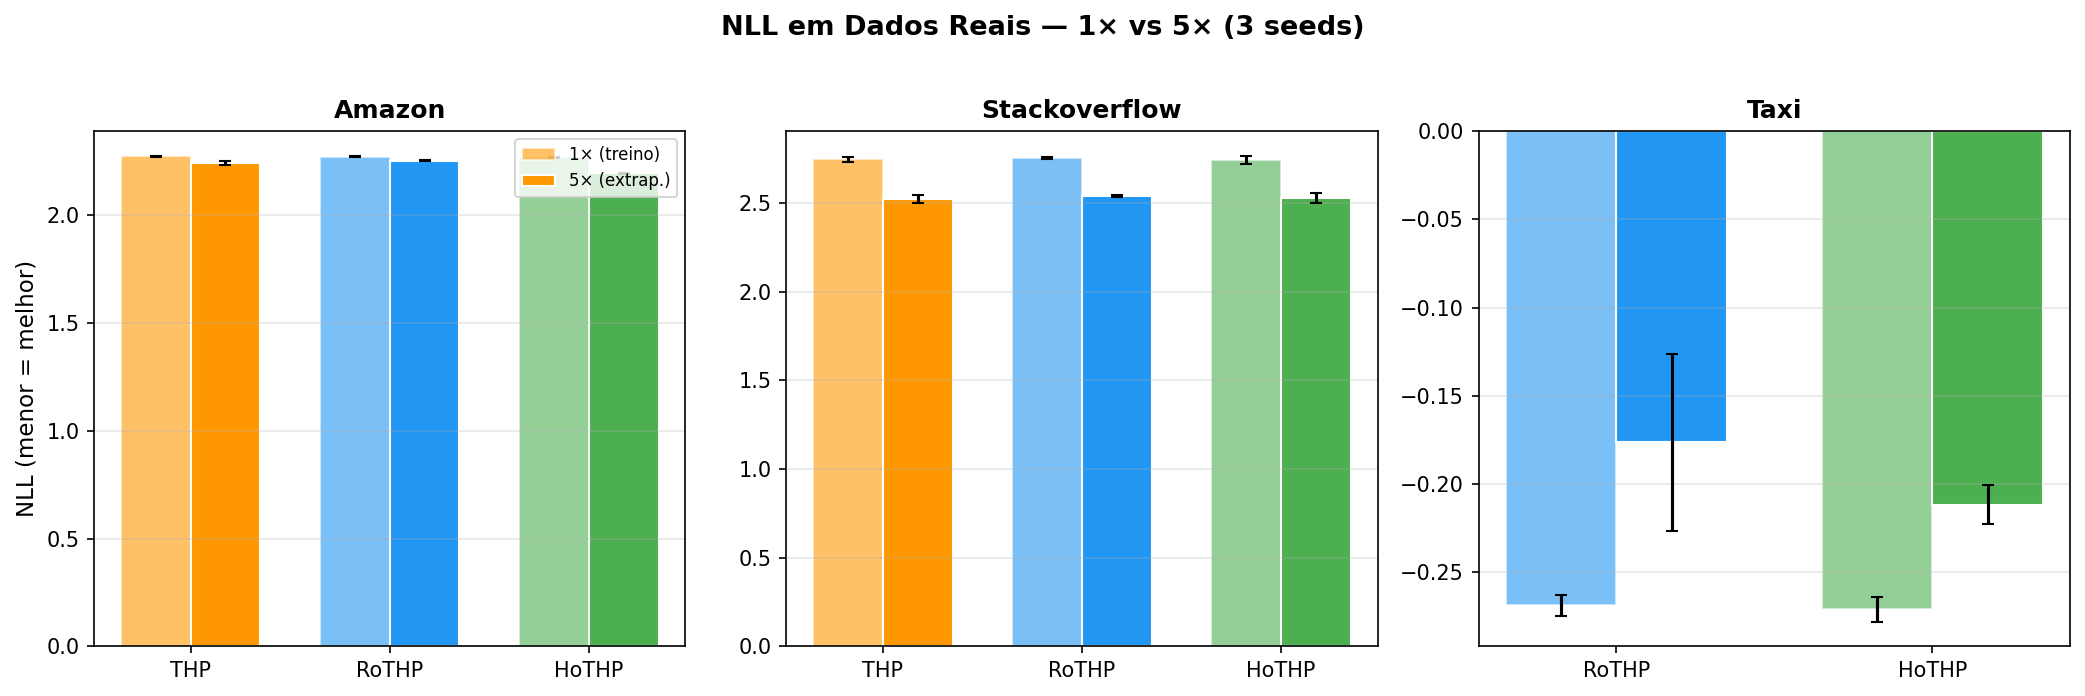

Salvo: ./figuras_dissertacao/fig_nll_real_datasets.{png,pdf}


In [155]:
# ── Figura 1: NLL comparativo por dataset (sem retweet) ──────────────

COLORS = {"THP": "#FF9800", "RoTHP": "#2196F3", "HoTHP": "#4CAF50"}
DS_CLEAN = ["amazon", "stackoverflow", "taxi"]  # retweet excluido pela escala

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

for ax_idx, ds in enumerate(DS_CLEAN):
    ax = axes[ax_idx]
    models = MODELS_PER_DS[ds]
    n_models = len(models)
    x = np.arange(n_models)
    width = 0.35

    means_1x, stds_1x = [], []
    means_5x, stds_5x = [], []
    for model in models:
        s = summarize(df_all, ds, model, "raw")
        means_1x.append(s["1x"]["nll"][0])
        stds_1x.append(s["1x"]["nll"][1])
        means_5x.append(s["5x"]["nll"][0])
        stds_5x.append(s["5x"]["nll"][1])

    bars1 = ax.bar(x - width/2, means_1x, width, yerr=stds_1x,
                   capsize=3, label="1× (treino)", color=[COLORS[m] for m in models],
                   alpha=0.6, edgecolor="white")
    bars5 = ax.bar(x + width/2, means_5x, width, yerr=stds_5x,
                   capsize=3, label="5× (extrap.)", color=[COLORS[m] for m in models],
                   alpha=1.0, edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_ylabel("NLL (menor = melhor)" if ax_idx == 0 else "")
    ax.set_title(ds.capitalize(), fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

    if ax_idx == 0:
        ax.legend(fontsize=8, loc="upper right")

fig.suptitle("NLL em Dados Reais — 1× vs 5× (3 seeds)", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_nll_real_datasets.png"), dpi=300)
fig.savefig(os.path.join(FIG_DIR, "fig_nll_real_datasets.pdf"))
plt.show()
print(f"Salvo: {FIG_DIR}/fig_nll_real_datasets.{{png,pdf}}")

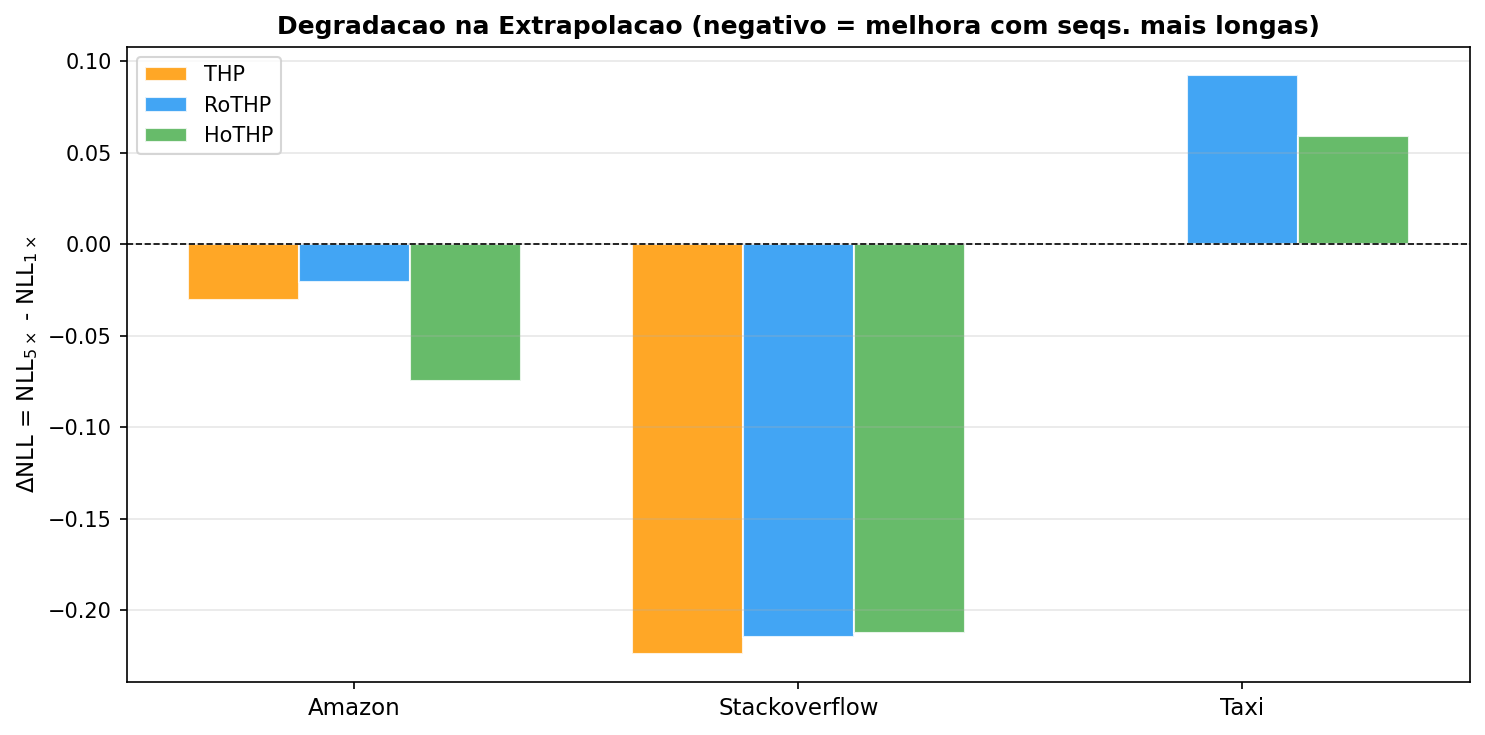

Salvo: ./figuras_dissertacao/fig_delta_nll.{png,pdf}


In [156]:
# ── Figura 2: Delta NLL (degradacao na extrapolacao) ─────────────────
# Mostra quanto cada modelo degrada ao ir de 1x para 5x

fig, ax = plt.subplots(figsize=(10, 5))

ds_labels = []
delta_data = {}  # model -> list of deltas

all_models = ["THP", "RoTHP", "HoTHP"]
for m in all_models:
    delta_data[m] = []

for ds in DS_CLEAN:
    ds_labels.append(ds.capitalize())
    models = MODELS_PER_DS[ds]
    for m in all_models:
        if m in models:
            s = summarize(df_all, ds, m, "raw")
            delta_data[m].append(s["delta_nll"])
        else:
            delta_data[m].append(np.nan)

x = np.arange(len(ds_labels))
width = 0.25

for i, model in enumerate(all_models):
    vals = delta_data[model]
    mask = [not np.isnan(v) for v in vals]
    positions = x[mask] + (i - 1) * width
    values = [v for v in vals if not np.isnan(v)]
    ax.bar(positions, values, width, label=model, color=COLORS[model],
           alpha=0.85, edgecolor="white")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(ds_labels, fontsize=11)
ax.set_ylabel("$\\Delta$NLL = NLL$_{5\\times}$ - NLL$_{1\\times}$")
ax.set_title("Degradacao na Extrapolacao (negativo = melhora com seqs. mais longas)",
             fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_delta_nll.png"), dpi=300)
fig.savefig(os.path.join(FIG_DIR, "fig_delta_nll.pdf"))
plt.show()
print(f"Salvo: {FIG_DIR}/fig_delta_nll.{{png,pdf}}")

---
## 3. Ablacao: Retweet Normalizado vs Cru

Corresponde a `\ref{tab:ablacao-retweet}` e `\ref{sec:ablacao-retweet}` na dissertacao.
Compara RoTHP e HoTHP no retweet com dados crus vs normalizados (dt/mean).

In [157]:
# ── Tabela: Ablacao retweet por seed ──────────────────────────────────

print("=" * 110)
print("ABLACAO RETWEET — Resultados por seed")
print("=" * 110)

for condition, label in [("raw", "ORIGINAL (dados crus)"), ("normalized", "NORMALIZADO (dt/mean)")]:
    print(f"\n--- {label} ---")
    print(f"{'Model':<8} {'Seed':>5}  {'NLL 1x':>12} {'NLL 5x':>14} {'Acc 1x':>8} {'Acc 5x':>8}")
    print("-" * 60)

    for model in ["RoTHP", "HoTHP"]:
        for seed in SEEDS:
            sub = df_all[(df_all["dataset"] == "retweet") &
                         (df_all["model"] == model) &
                         (df_all["seed"] == seed) &
                         (df_all["condition"] == condition)]
            r1 = sub[sub["extrap"] == "1x"]
            r5 = sub[sub["extrap"] == "5x"]

            n1 = f"{r1['nll'].values[0]:.4f}" if len(r1) else "---"
            n5 = f"{r5['nll'].values[0]:.4f}" if len(r5) else "---"
            a1 = f"{r1['acc'].values[0]:.4f}" if len(r1) else "---"
            a5 = f"{r5['acc'].values[0]:.4f}" if len(r5) else "---"

            print(f"{model:<8} {seed:>5}  {n1:>12} {n5:>14} {a1:>8} {a5:>8}")
        print()

ABLACAO RETWEET — Resultados por seed

--- ORIGINAL (dados crus) ---
Model     Seed        NLL 1x         NLL 5x   Acc 1x   Acc 5x
------------------------------------------------------------
RoTHP     2019        5.4836         7.5710   0.5791   0.5793
RoTHP     2020       15.9425        15.9433   0.4536   0.4909
RoTHP     2021       15.9425    362906.1400   0.4538   0.4910

HoTHP     2019        5.6672         8.1478   0.5774   0.5731
HoTHP     2020       15.9425     69716.8157   0.4536   0.4909
HoTHP     2021       15.9425   1030829.4275   0.4541   0.4911


--- NORMALIZADO (dt/mean) ---
Model     Seed        NLL 1x         NLL 5x   Acc 1x   Acc 5x
------------------------------------------------------------
RoTHP     2019       -2.1370       255.9303   0.5811   0.5763
RoTHP     2020       -2.3820        -0.3107   0.6265   0.5599
RoTHP     2021       -2.0722        10.9471   0.5561   0.5486

HoTHP     2019       -2.1757        -0.5458   0.5899   0.5837
HoTHP     2020       -2.1711   

In [158]:
# ── Tabela resumo: Ablacao (media +/- std) ────────────────────────────

print("=" * 100)
print("ABLACAO RETWEET — Media ± Std (3 seeds)")
print("=" * 100)
print(f"{'Versao':<15} {'Model':<8} {'NLL 1x':>20} {'NLL 5x':>20} {'Acc 1x':>16} {'Acc 5x':>16}")
print("-" * 100)

for cond, label in [("raw", "Original"), ("normalized", "Normalizado")]:
    for model in ["RoTHP", "HoTHP"]:
        s = summarize(df_all, "retweet", model, cond)
        n1 = fmt_pm(*s["1x"]["nll"])
        n5 = fmt_pm(*s["5x"]["nll"])
        a1 = fmt_pm(*s["1x"]["acc"])
        a5 = fmt_pm(*s["5x"]["acc"])
        lbl = label if model == "RoTHP" else ""
        print(f"{lbl:<15} {model:<8} {n1:>20} {n5:>20} {a1:>16} {a5:>16}")
    print()

ABLACAO RETWEET — Media ± Std (3 seeds)
Versao          Model                  NLL 1x               NLL 5x           Acc 1x           Acc 5x
----------------------------------------------------------------------------------------------------
Original        RoTHP          12.456 ± 6.038 120976.551 ± 209517.170    0.496 ± 0.072    0.520 ± 0.051
                HoTHP          12.517 ± 5.932 366851.464 ± 576077.145    0.495 ± 0.071    0.518 ± 0.047

Normalizado     RoTHP          -2.197 ± 0.163     88.856 ± 144.800    0.588 ± 0.036    0.562 ± 0.014
                HoTHP          -2.168 ± 0.010       -0.542 ± 0.004    0.591 ± 0.002    0.588 ± 0.004



In [159]:
# ── Tabela LaTeX: tab:ablacao-retweet ─────────────────────────────────

print(r"""\begin{table}[h!]
\centering
\caption{Ablação: efeito da normalização temporal no Retweet. ``Original'' usa os timestamps brutos; ``Normalizado'' usa os timestamps divididos pela média dos gaps. Média $\pm$ desvio padrão (3 sementes).}
\label{tab:ablacao-retweet}
\begin{tabular}{llcccc}
\toprule
Versão & Modelo & NLL $1\times$ & NLL $5\times$ & Acc $1\times$ & Acc $5\times$ \\
\midrule""")

for cond, label in [("raw", "Original"), ("normalized", "Normalizado")]:
    models = ["RoTHP", "HoTHP"]
    for i, model in enumerate(models):
        s = summarize(df_all, "retweet", model, cond)
        n1 = fmt_pm_latex(*s["1x"]["nll"])
        a1 = fmt_pm_latex(*s["1x"]["acc"])
        a5 = fmt_pm_latex(*s["5x"]["acc"])

        # Para NLL 5x no caso cru, usar notacao cientifica
        nll5_mean, nll5_std = s["5x"]["nll"]
        if abs(nll5_mean) > 1000:
            exp = int(np.floor(np.log10(abs(nll5_mean))))
            coeff = nll5_mean / 10**exp
            n5 = f"${coeff:.0f} \\times 10^{{{exp}}}$"
        else:
            n5 = fmt_pm_latex(nll5_mean, nll5_std)
            # Bold the best (HoTHP normalized)
            if cond == "normalized" and model == "HoTHP":
                n5 = fmt_pm_latex(nll5_mean, nll5_std, bold=True)

        prefix = f"\\multirow{{2}}{{*}}{{{label}}}" if i == 0 else "    "
        print(f"    {prefix} & {model} & {n1} & {n5} & {a1} & {a5} \\\\")

    if cond == "raw":
        print(r"\midrule")

print(r"""\bottomrule
\end{tabular}
\end{table}""")

\begin{table}[h!]
\centering
\caption{Ablação: efeito da normalização temporal no Retweet. ``Original'' usa os timestamps brutos; ``Normalizado'' usa os timestamps divididos pela média dos gaps. Média $\pm$ desvio padrão (3 sementes).}
\label{tab:ablacao-retweet}
\begin{tabular}{llcccc}
\toprule
Versão & Modelo & NLL $1\times$ & NLL $5\times$ & Acc $1\times$ & Acc $5\times$ \\
\midrule
    \multirow{2}{*}{Original} & RoTHP & $12{,}456 \pm 6{,}038$ & $1 \times 10^{5}$ & $0{,}496 \pm 0{,}072$ & $0{,}520 \pm 0{,}051$ \\
         & HoTHP & $12{,}517 \pm 5{,}932$ & $4 \times 10^{5}$ & $0{,}495 \pm 0{,}071$ & $0{,}518 \pm 0{,}047$ \\
\midrule
    \multirow{2}{*}{Normalizado} & RoTHP & $-2{,}197 \pm 0{,}163$ & $88{,}856 \pm 144{,}800$ & $0{,}588 \pm 0{,}036$ & $0{,}562 \pm 0{,}014$ \\
         & HoTHP & $-2{,}168 \pm 0{,}010$ & $\mathbf{-0{,}542 \pm 0{,}004}$ & $0{,}591 \pm 0{,}002$ & $0{,}588 \pm 0{,}004$ \\
\bottomrule
\end{tabular}
\end{table}


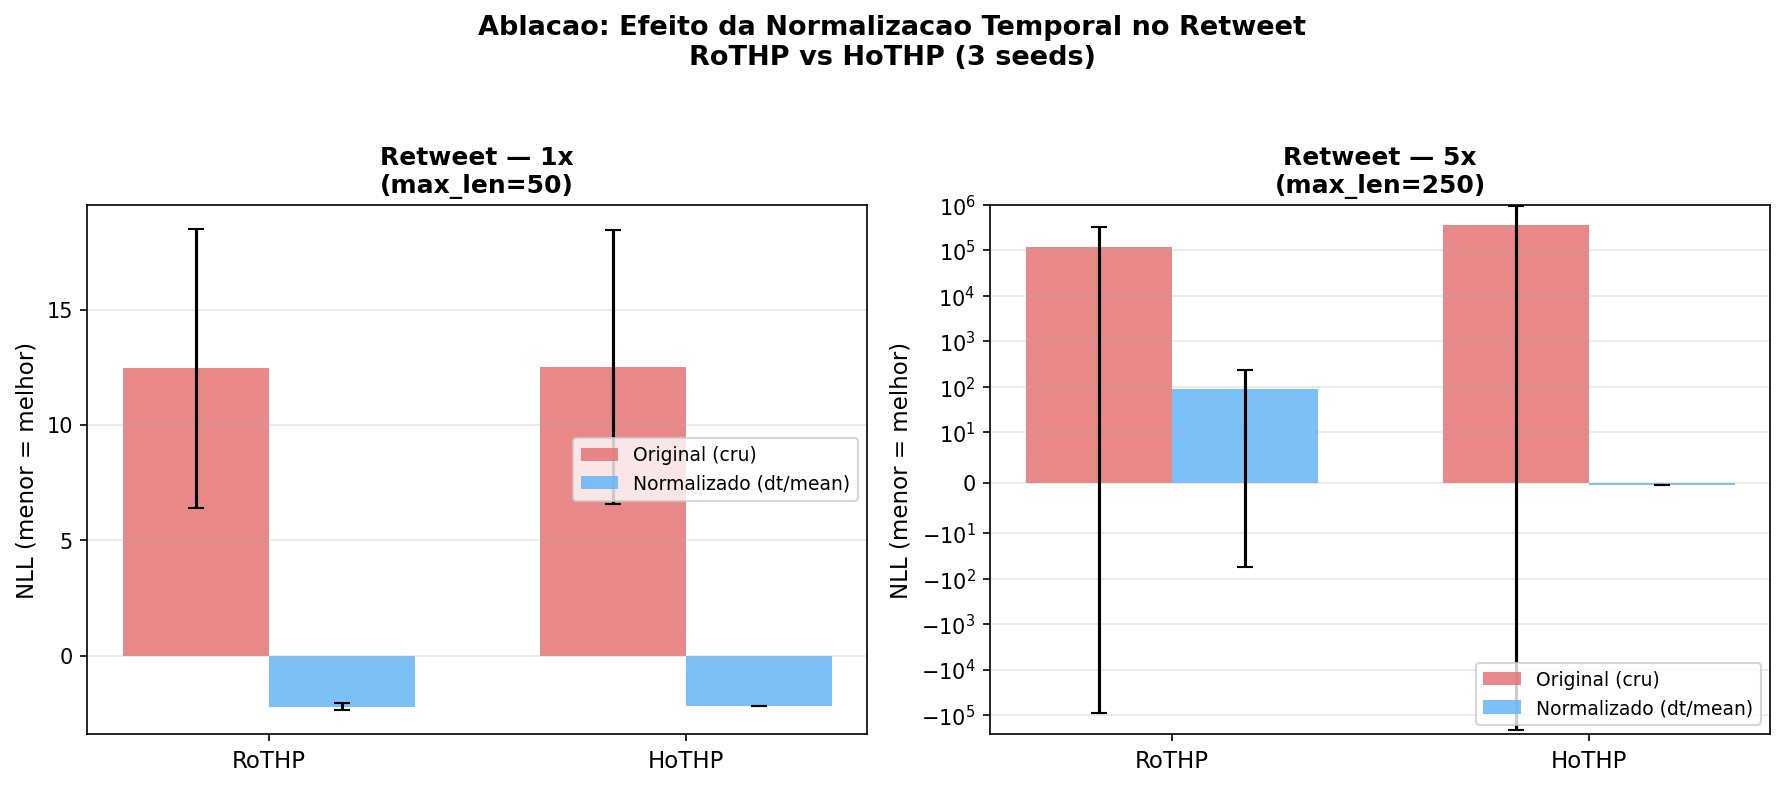

Salvo: ./figuras_dissertacao/fig_ablacao_retweet.{png,pdf}


In [160]:
# ── Figura 3: Ablacao retweet — cru vs normalizado ───────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax_idx, extrap in enumerate(["1x", "5x"]):
    ax = axes[ax_idx]
    models = ["RoTHP", "HoTHP"]
    x = np.arange(len(models))
    width = 0.35

    # Dados crus
    raw_means, raw_stds = [], []
    for m in models:
        s = summarize(df_all, "retweet", m, "raw")
        raw_means.append(s[extrap]["nll"][0])
        raw_stds.append(s[extrap]["nll"][1])

    # Dados normalizados
    norm_means, norm_stds = [], []
    for m in models:
        s = summarize(df_all, "retweet", m, "normalized")
        norm_means.append(s[extrap]["nll"][0])
        norm_stds.append(s[extrap]["nll"][1])

    bars1 = ax.bar(x - width/2, raw_means, width, yerr=raw_stds,
                   capsize=4, label="Original (cru)", color="#E57373", alpha=0.85)
    bars2 = ax.bar(x + width/2, norm_means, width, yerr=norm_stds,
                   capsize=4, label="Normalizado (dt/mean)", color="#64B5F6", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel("NLL (menor = melhor)")
    max_len = 50 if extrap == "1x" else 250
    ax.set_title(f"Retweet — {extrap}\n(max_len={max_len})", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

    # Escala log se valores sao muito grandes
    if extrap == "5x":
        ax.set_yscale("symlog", linthresh=10)

fig.suptitle("Ablacao: Efeito da Normalizacao Temporal no Retweet\n"
             "RoTHP vs HoTHP (3 seeds)", fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_ablacao_retweet.png"), dpi=300)
fig.savefig(os.path.join(FIG_DIR, "fig_ablacao_retweet.pdf"))
plt.show()
print(f"Salvo: {FIG_DIR}/fig_ablacao_retweet.{{png,pdf}}")

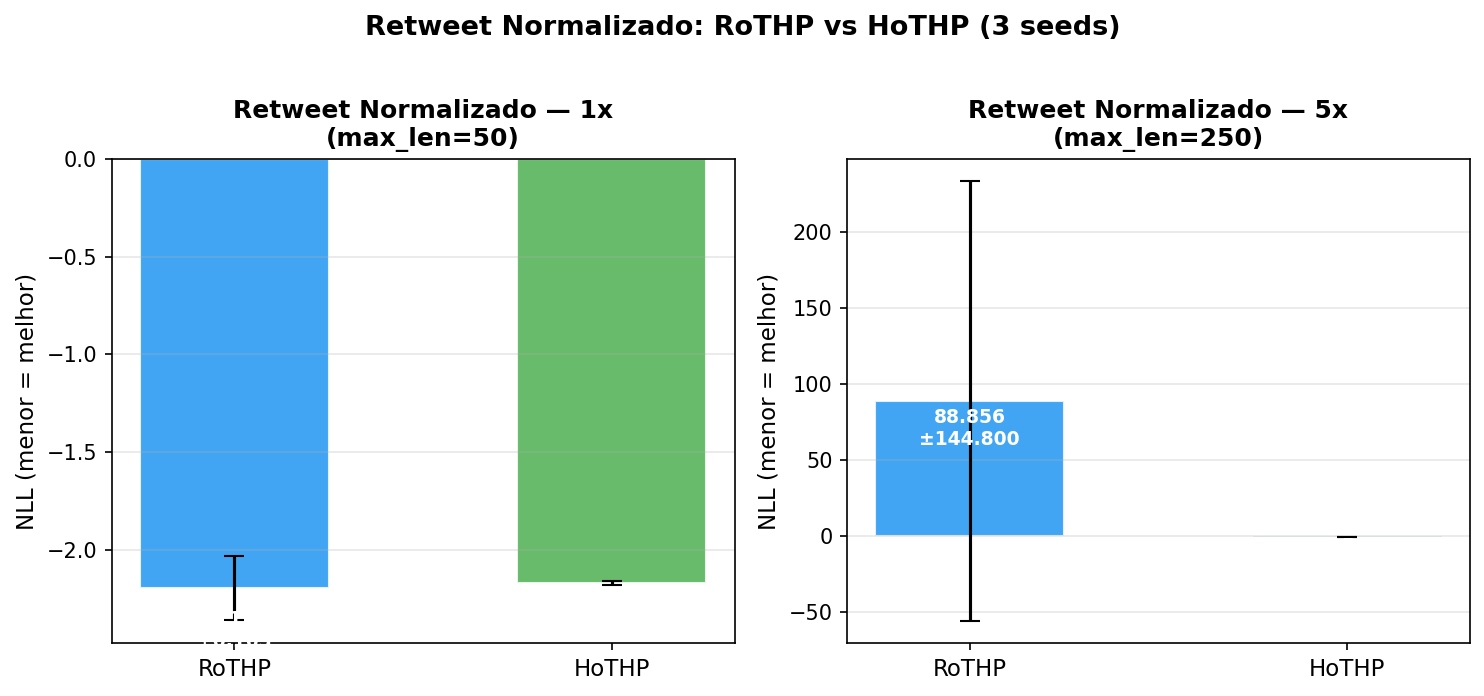

Salvo: ./figuras_dissertacao/fig_retweet_norm_only.{png,pdf}


In [161]:
# ── Figura 4: Foco no retweet normalizado (so barras azuis, sem escala maluca)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax_idx, extrap in enumerate(["1x", "5x"]):
    ax = axes[ax_idx]
    models = ["RoTHP", "HoTHP"]
    x = np.arange(len(models))

    means, stds = [], []
    for m in models:
        s = summarize(df_all, "retweet", m, "normalized")
        means.append(s[extrap]["nll"][0])
        stds.append(s[extrap]["nll"][1])

    colors = [COLORS[m] for m in models]
    bars = ax.bar(x, means, 0.5, yerr=stds, capsize=5,
                  color=colors, alpha=0.85, edgecolor="white")

    # Anotacoes
    for bar, mean, std in zip(bars, means, stds):
        y = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, y - abs(y)*0.05,
                f"{mean:.3f}\n±{std:.3f}", ha="center", va="top",
                fontsize=9, fontweight="bold", color="white")

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel("NLL (menor = melhor)")
    max_len = 50 if extrap == "1x" else 250
    ax.set_title(f"Retweet Normalizado — {extrap}\n(max_len={max_len})", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Retweet Normalizado: RoTHP vs HoTHP (3 seeds)",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_retweet_norm_only.png"), dpi=300)
fig.savefig(os.path.join(FIG_DIR, "fig_retweet_norm_only.pdf"))
plt.show()
print(f"Salvo: {FIG_DIR}/fig_retweet_norm_only.{{png,pdf}}")

---
## 4. Figura Consolidada: Todos os datasets num unico grafico

Painel 2x2 mostrando NLL 5x para cada dataset. Inclui retweet normalizado como referencia.

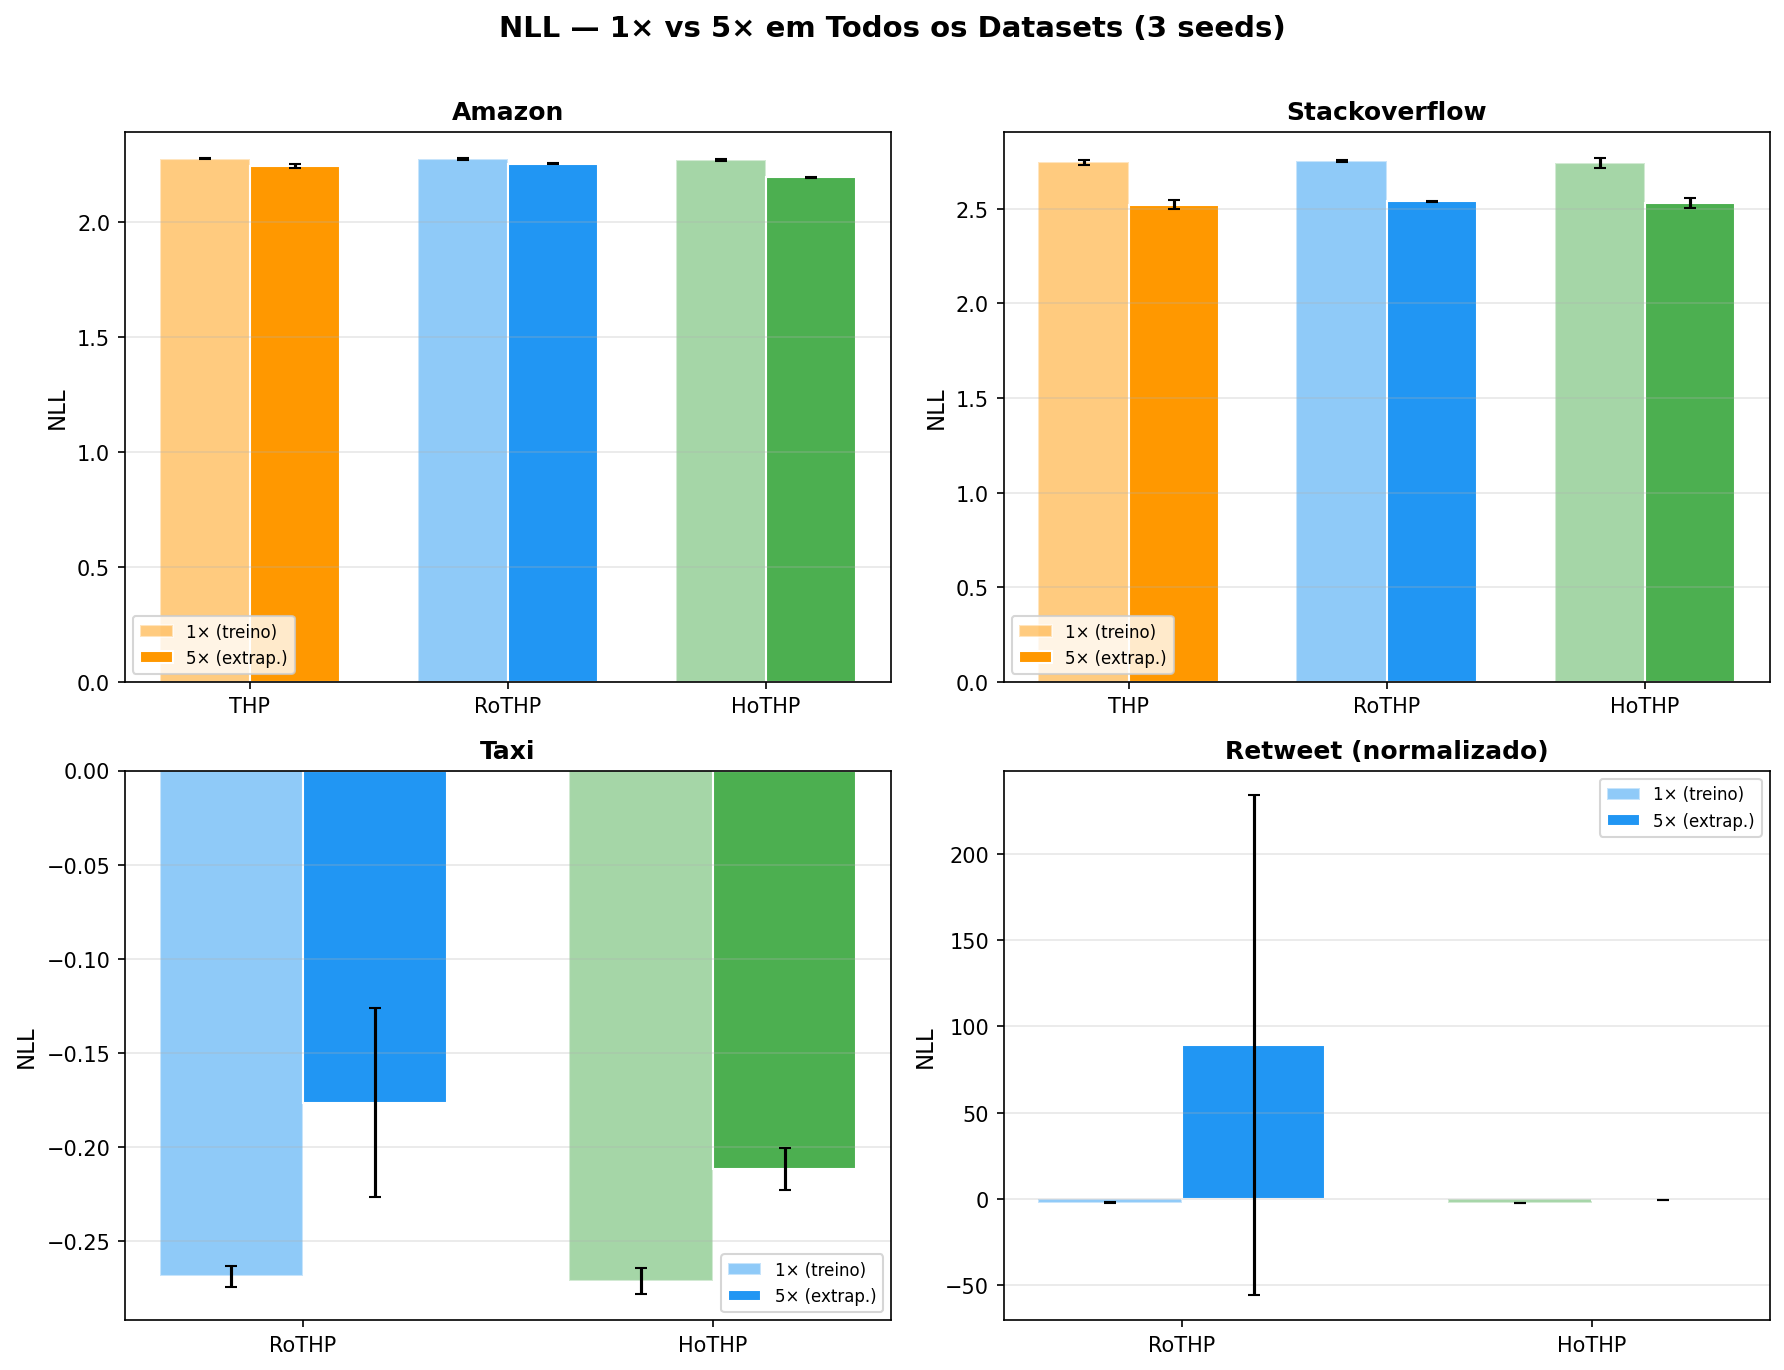

Salvo: ./figuras_dissertacao/fig_painel_consolidado.{png,pdf}


In [162]:
# ── Figura 5: Painel consolidado 2x2 ─────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Configuracao de cada painel
panels = [
    {"ds": "amazon",        "cond": "raw", "title": "Amazon", "models": ["THP", "RoTHP", "HoTHP"]},
    {"ds": "stackoverflow", "cond": "raw", "title": "Stackoverflow", "models": ["THP", "RoTHP", "HoTHP"]},
    {"ds": "taxi",          "cond": "raw", "title": "Taxi", "models": ["RoTHP", "HoTHP"]},
    {"ds": "retweet",       "cond": "normalized", "title": "Retweet (normalizado)", "models": ["RoTHP", "HoTHP"]},
]

for ax, panel in zip(axes.ravel(), panels):
    models = panel["models"]
    x = np.arange(len(models))
    width = 0.35

    means_1x, stds_1x, means_5x, stds_5x = [], [], [], []
    for m in models:
        s = summarize(df_all, panel["ds"], m, panel["cond"])
        means_1x.append(s["1x"]["nll"][0])
        stds_1x.append(s["1x"]["nll"][1])
        means_5x.append(s["5x"]["nll"][0])
        stds_5x.append(s["5x"]["nll"][1])

    ax.bar(x - width/2, means_1x, width, yerr=stds_1x, capsize=3,
           color=[COLORS[m] for m in models], alpha=0.5, edgecolor="white",
           label="1× (treino)")
    ax.bar(x + width/2, means_5x, width, yerr=stds_5x, capsize=3,
           color=[COLORS[m] for m in models], alpha=1.0, edgecolor="white",
           label="5× (extrap.)")

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_ylabel("NLL")
    ax.set_title(panel["title"], fontweight="bold", fontsize=12)
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend(fontsize=8)

fig.suptitle("NLL — 1× vs 5× em Todos os Datasets (3 seeds)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_painel_consolidado.png"), dpi=300)
fig.savefig(os.path.join(FIG_DIR, "fig_painel_consolidado.pdf"))
plt.show()
print(f"Salvo: {FIG_DIR}/fig_painel_consolidado.{{png,pdf}}")

---
## 5. Tempos de Treino

Tempos de execucao no Colab (A100-SXM4-80GB para benchmark, A100-SXM4-40GB para ablacao).

In [163]:
# ── Tempos de treino ──────────────────────────────────────────────────

print("=" * 70)
print("TEMPOS DE TREINO — Benchmark (dados crus)")
print(f"GPU: {hardware['gpu_name']}, {hardware['gpu_vram_gb']}GB VRAM")
print("=" * 70)

# Benchmark: chaves sao tuplas (dataset, model, seed)
bench_times = {}
for key, secs in train_times_bench.items():
    ds, model, seed = key
    if ds not in bench_times:
        bench_times[ds] = {}
    if model not in bench_times[ds]:
        bench_times[ds][model] = []
    bench_times[ds][model].append(secs)

print(f"\n{'Dataset':<15} {'Model':<8} {'Media':>8} {'Min':>8} {'Max':>8}")
print("-" * 50)
for ds in DATASETS_ORDER:
    if ds not in bench_times:
        continue
    for model in ["THP", "RoTHP", "HoTHP"]:
        if model not in bench_times.get(ds, {}):
            continue
        times = bench_times[ds][model]
        m = np.mean(times)
        print(f"{ds:<15} {model:<8} {m/60:7.1f}m {min(times)/60:7.1f}m {max(times)/60:7.1f}m")

# Ablacao: chaves sao strings "Model_seedN"
print(f"\n{'='*70}")
print("TEMPOS DE TREINO — Ablacao retweet normalizado")
print(f"GPU: NVIDIA A100-SXM4-40GB")
print(f"{'='*70}")
print(f"\n{'Model':<8} {'Media':>8}")
print("-" * 20)
for model in ["RoTHP", "HoTHP"]:
    times = [v for k, v in train_times_ablation.items() if k.startswith(model)]
    if times:
        print(f"{model:<8} {np.mean(times)/60:7.1f}m")

TEMPOS DE TREINO — Benchmark (dados crus)
GPU: NVIDIA A100-SXM4-80GB, 79.25GB VRAM

Dataset         Model       Media      Min      Max
--------------------------------------------------
amazon          THP          9.3m     9.2m     9.3m
amazon          RoTHP        9.4m     9.4m     9.4m
amazon          HoTHP       11.8m    11.8m    11.8m
stackoverflow   THP          2.4m     2.4m     2.4m
stackoverflow   RoTHP        2.4m     2.4m     2.4m
stackoverflow   HoTHP        3.1m     3.1m     3.1m
taxi            RoTHP        1.9m     1.9m     2.0m
taxi            HoTHP        2.0m     2.0m     2.0m
retweet         RoTHP       34.3m    34.3m    34.4m
retweet         HoTHP       76.6m    76.5m    76.7m

TEMPOS DE TREINO — Ablacao retweet normalizado
GPU: NVIDIA A100-SXM4-40GB

Model       Media
--------------------
RoTHP       43.5m
HoTHP       97.6m


---
## 5b. Curvas de Convergencia (extraidas dos logs de treino)

Parseia os arquivos `log` dentro dos checkpoints para extrair a loglike de treino e
validacao por epoca. Gera graficos de convergencia para cada dataset.

**Requer:** `data/benchmark_checkpoints.zip` (e opcionalmente `benchmark_checkpoints_old.zip`)

In [164]:
# ── Extrair curvas de convergencia dos logs ───────────────────────────

import zipfile, re

def parse_training_logs(zip_path):
    """Extrai loglike de treino e validacao por epoca de cada log dentro do zip.
    
    CUIDADO: o EasyTPP loga todas as runs no mesmo arquivo (root logger compartilhado).
    Entao o log de amazon/RoTHP/seed2019 pode conter epochs de TODAS as runs seguintes.
    Solucao: pegar so o primeiro ciclo completo (epoch 0 ate epoch 99), parando na
    segunda ocorrencia de epoch 0.
    
    Retorna dict: (dataset, model, seed) -> {"train": [(epoch, loglike)], "valid": [...]}
    """
    train_pat = re.compile(r'Epoch (\d+) \(train\).*?train loglike is ([0-9.e+-]+)')
    valid_pat = re.compile(r'Epoch (\d+) \(valid\).*?valid loglike is ([0-9.e+-]+)')

    results = {}

    with zipfile.ZipFile(zip_path) as z:
        # Identificar diretorios de treino (contem train_output.yaml)
        train_dirs = {}
        for f in z.namelist():
            if f.endswith('train_output.yaml'):
                parts = f.split('/')
                # checkpoints/<dataset>/<model>/<seedN>/<run_id>/train_output.yaml
                if len(parts) >= 5:
                    ds = parts[1]
                    model = parts[2]
                    seed_str = parts[3]  # e.g. "seed2019"
                    seed = int(seed_str.replace('seed', ''))
                    run_dir = '/'.join(parts[:-1])
                    train_dirs[(ds, model, seed)] = run_dir

        for key, run_dir in train_dirs.items():
            log_path = run_dir + '/log'
            if log_path not in z.namelist():
                continue

            content = z.read(log_path).decode('utf-8', errors='replace')

            raw_train = [(int(e), float(v)) for e, v in train_pat.findall(content)]
            raw_valid = [(int(e), float(v)) for e, v in valid_pat.findall(content)]

            # Pegar so o PRIMEIRO ciclo: do primeiro epoch 0 ate antes do segundo epoch 0
            def first_cycle(pairs):
                if not pairs:
                    return []
                cycle = [pairs[0]]
                for i in range(1, len(pairs)):
                    if pairs[i][0] == 0:
                        break  # segundo ciclo comecou
                    cycle.append(pairs[i])
                return cycle

            results[key] = {
                "train": first_cycle(raw_train),
                "valid": first_cycle(raw_valid),
            }

    return results


# Parsear ambos os zips
convergence = {}
for zip_name in ["benchmark_checkpoints.zip", "benchmark_checkpoints_old.zip"]:
    zip_path = os.path.join(DATA_DIR, zip_name)
    if os.path.exists(zip_path):
        logs = parse_training_logs(zip_path)
        # Merge (novo sobrescreve velho se houver duplicata)
        for k, v in logs.items():
            if k not in convergence or len(v["train"]) > len(convergence[k]["train"]):
                convergence[k] = v
        print(f"{zip_name}: {len(logs)} train logs encontrados")
    else:
        print(f"{zip_name}: NAO ENCONTRADO")

# Resumo
print(f"\nTotal: {len(convergence)} runs com logs de convergencia")
for key in sorted(convergence.keys()):
    ds, model, seed = key
    n_train = len(convergence[key]["train"])
    n_valid = len(convergence[key]["valid"])
    print(f"  {ds:<15} {model:<8} seed={seed}  train={n_train} epochs, valid={n_valid} epochs")

benchmark_checkpoints.zip: 30 train logs encontrados
benchmark_checkpoints_old.zip: 18 train logs encontrados

Total: 30 runs com logs de convergencia
  amazon          HoTHP    seed=2019  train=100 epochs, valid=100 epochs
  amazon          HoTHP    seed=2020  train=100 epochs, valid=100 epochs
  amazon          HoTHP    seed=2021  train=100 epochs, valid=100 epochs
  amazon          RoTHP    seed=2019  train=100 epochs, valid=100 epochs
  amazon          RoTHP    seed=2020  train=100 epochs, valid=100 epochs
  amazon          RoTHP    seed=2021  train=100 epochs, valid=100 epochs
  amazon          THP      seed=2019  train=100 epochs, valid=100 epochs
  amazon          THP      seed=2020  train=100 epochs, valid=100 epochs
  amazon          THP      seed=2021  train=100 epochs, valid=100 epochs
  retweet         HoTHP    seed=2019  train=100 epochs, valid=100 epochs
  retweet         HoTHP    seed=2020  train=100 epochs, valid=100 epochs
  retweet         HoTHP    seed=2021  train=10

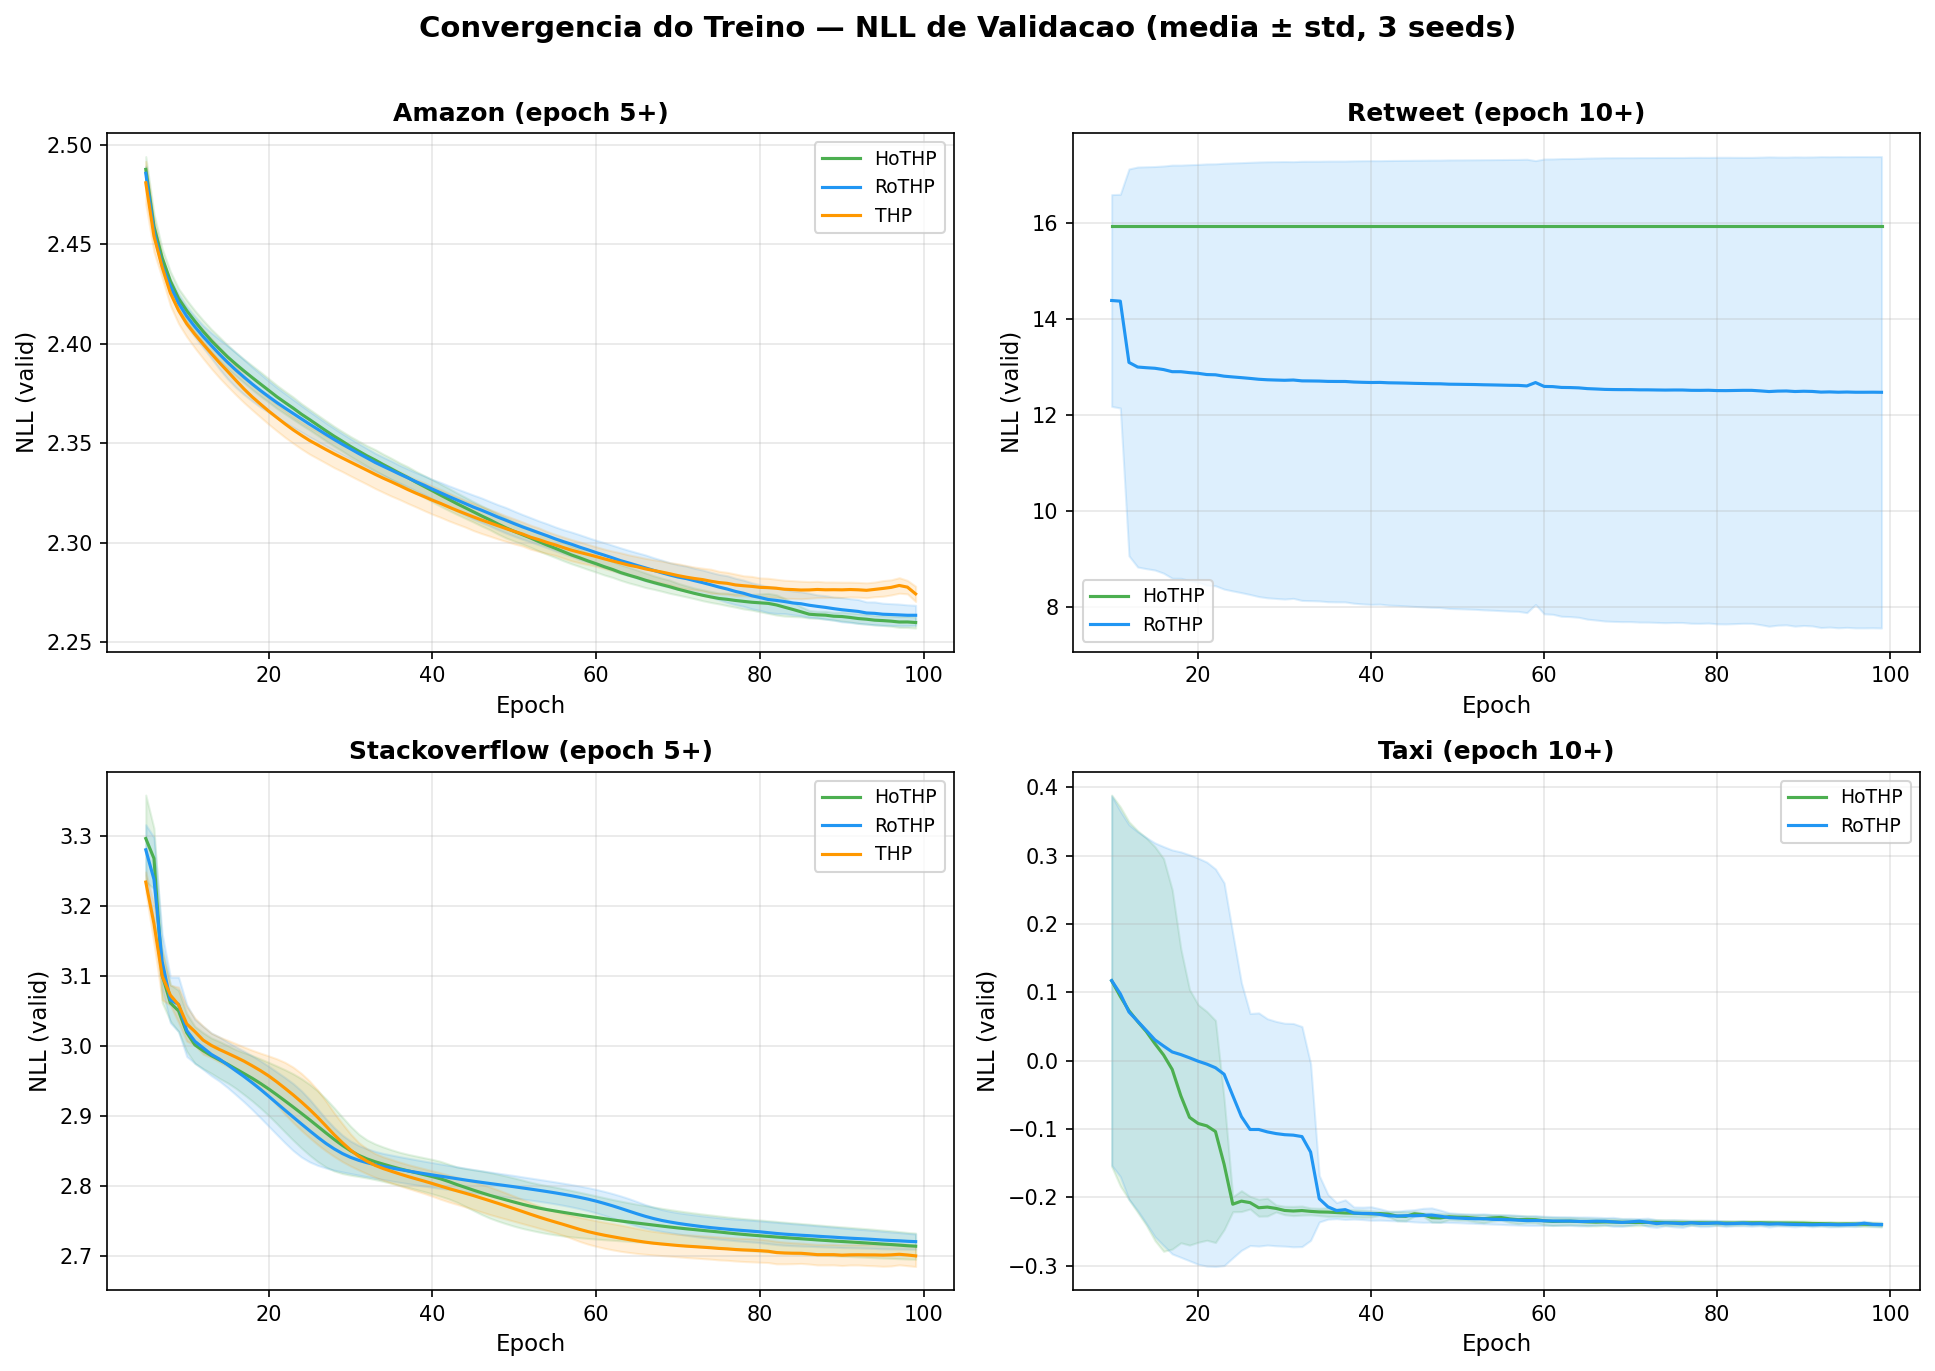

Salvo: ./figuras_dissertacao/fig_convergencia.{png,pdf}


In [165]:
# ── Figura 6: Curvas de convergencia (validacao) por dataset ─────────
# Pula as primeiras epocas para focar na convergencia real.

SKIP_EPOCHS = {
    "amazon": 5,
    "stackoverflow": 5,
    "taxi": 10,
    "retweet": 10,
}

ds_with_logs = sorted(set(k[0] for k in convergence.keys()))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax_idx, ds in enumerate(ds_with_logs):
    ax = axes[ax_idx]
    skip = SKIP_EPOCHS.get(ds, 5)
    models_in_ds = sorted(set(k[1] for k in convergence if k[0] == ds))

    for model in models_in_ds:
        all_curves = []
        for seed in SEEDS:
            key = (ds, model, seed)
            if key in convergence and convergence[key]["valid"]:
                values = [v for e, v in convergence[key]["valid"]]
                all_curves.append(values)

        if not all_curves:
            continue

        min_len = min(len(c) for c in all_curves)
        aligned = np.array([c[:min_len] for c in all_curves])
        mean_curve = aligned.mean(axis=0)
        std_curve = aligned.std(axis=0)

        # Cortar as primeiras epocas
        ep = np.arange(skip, min_len)
        mc = -mean_curve[skip:]
        sc = std_curve[skip:]

        color = COLORS.get(model, "gray")
        ax.plot(ep, mc, color=color, linewidth=1.5, label=model)
        ax.fill_between(ep, mc - sc, mc + sc, color=color, alpha=0.15)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("NLL (valid)")
    ax.set_title(f"{ds.capitalize()} (epoch {skip}+)", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Convergencia do Treino — NLL de Validacao (media ± std, 3 seeds)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_convergencia.png"), dpi=300)
fig.savefig(os.path.join(FIG_DIR, "fig_convergencia.pdf"))
plt.show()
print(f"Salvo: {FIG_DIR}/fig_convergencia.{{png,pdf}}")

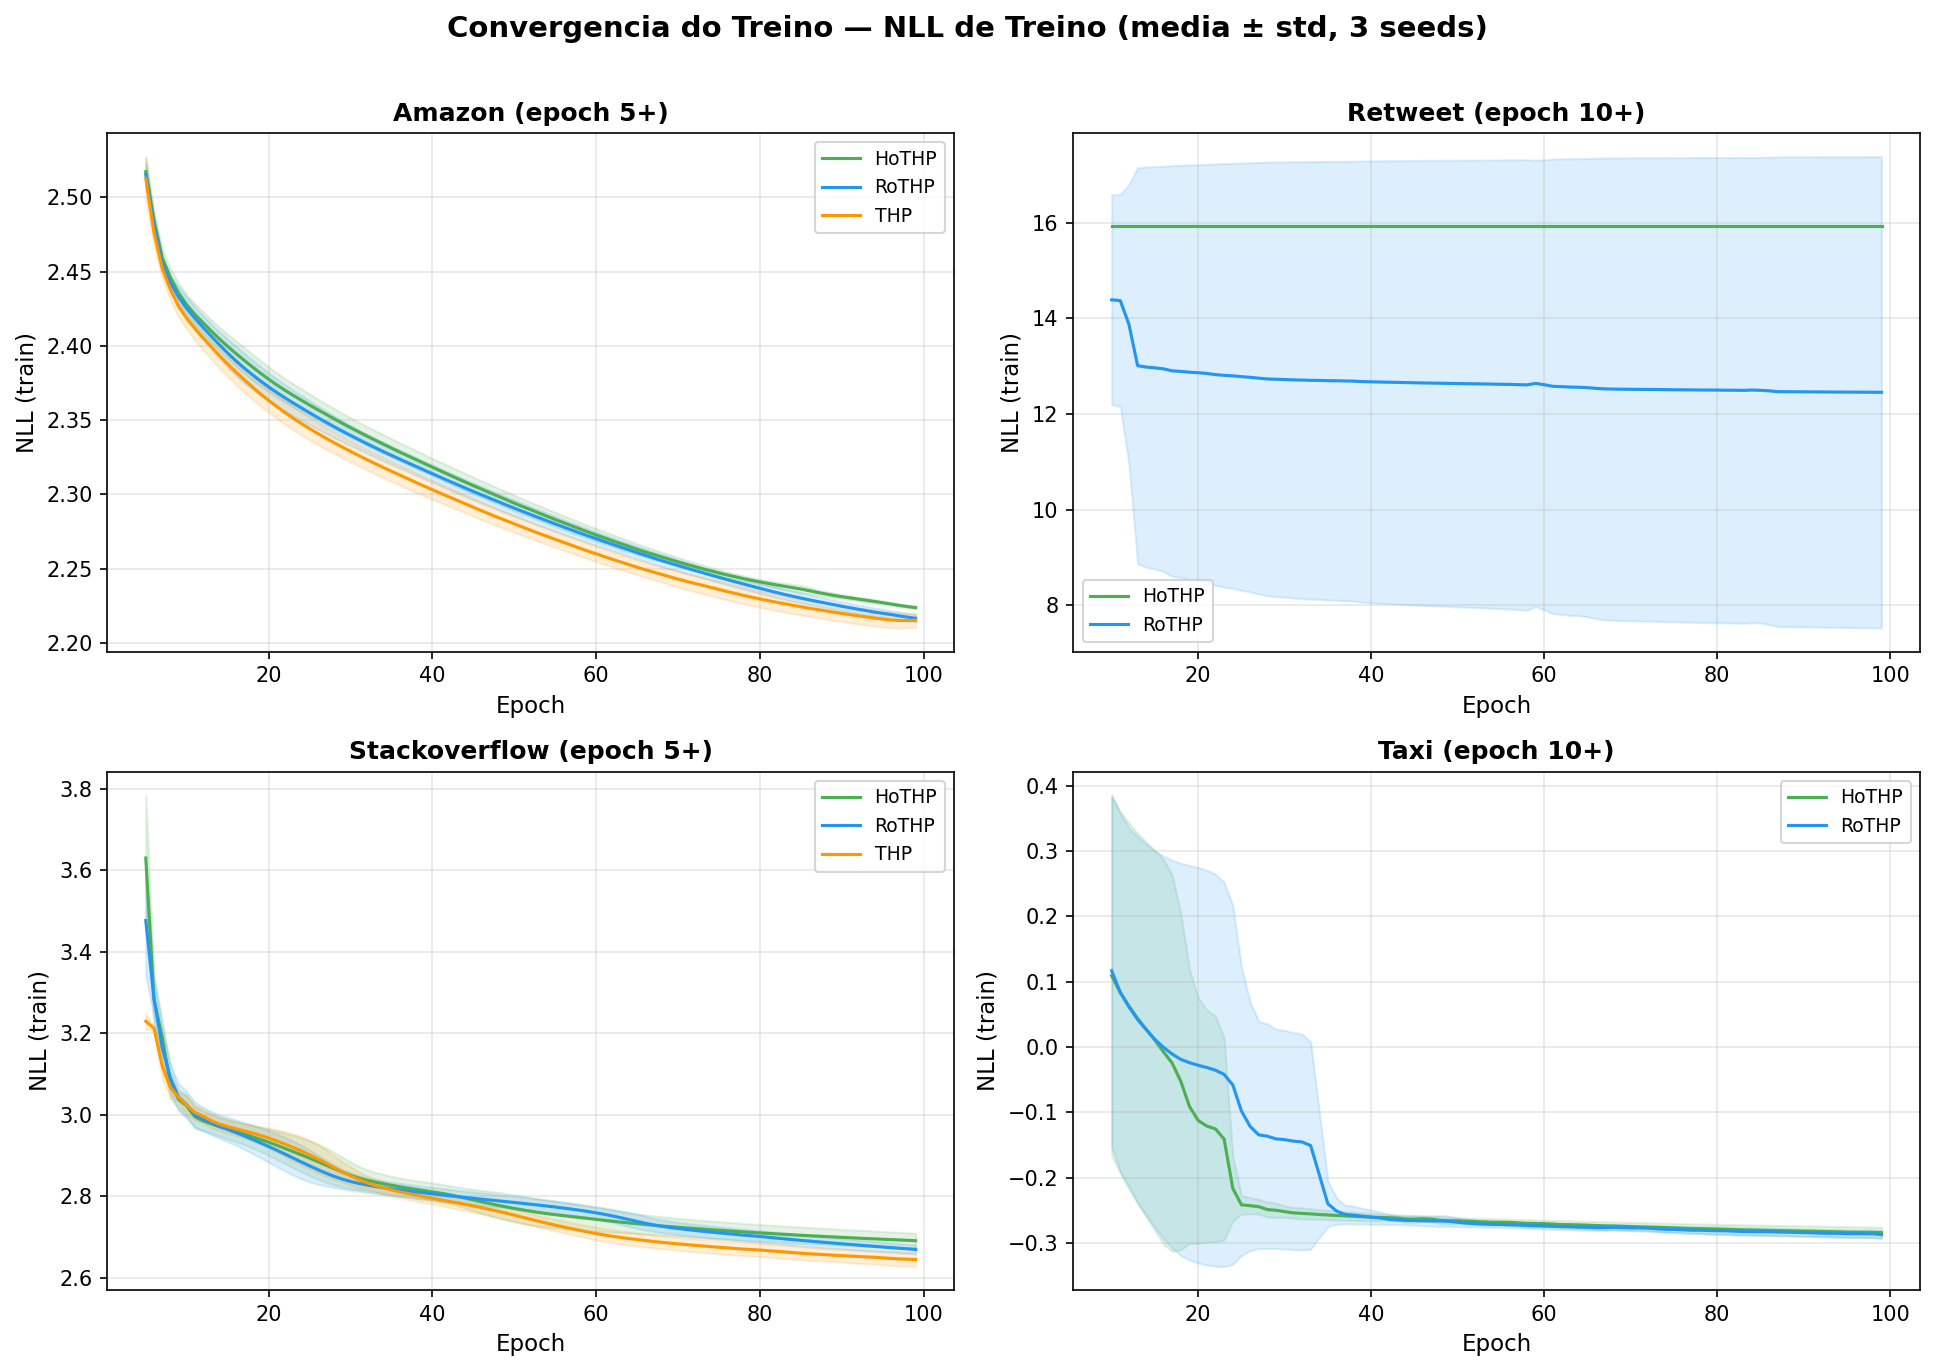

Salvo: ./figuras_dissertacao/fig_convergencia_train.{png,pdf}


In [166]:
# ── Figura 7: Convergencia do treino (train NLL) ─────────────────────
# Pula as primeiras epocas (skip_epochs) para focar na convergencia real,
# evitando que o spike da epoch 0 esmague a escala do grafico.

SKIP_EPOCHS = {
    "amazon": 5,
    "stackoverflow": 5,
    "taxi": 10,        # spike inicial muito grande (~2e6), precisa cortar mais
    "retweet": 10,     # idem (~2.3e6)
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax_idx, ds in enumerate(ds_with_logs):
    ax = axes[ax_idx]
    skip = SKIP_EPOCHS.get(ds, 5)
    models_in_ds = sorted(set(k[1] for k in convergence if k[0] == ds))

    for model in models_in_ds:
        all_curves = []
        for seed in SEEDS:
            key = (ds, model, seed)
            if key in convergence and convergence[key]["train"]:
                values = [v for e, v in convergence[key]["train"]]
                all_curves.append(values)

        if not all_curves:
            continue

        min_len = min(len(c) for c in all_curves)
        aligned = np.array([c[:min_len] for c in all_curves])
        mean_curve = aligned.mean(axis=0)
        std_curve = aligned.std(axis=0)

        # Cortar as primeiras epocas
        ep = np.arange(skip, min_len)
        mc = -mean_curve[skip:]
        sc = std_curve[skip:]

        color = COLORS.get(model, "gray")
        ax.plot(ep, mc, color=color, linewidth=1.5, label=model)
        ax.fill_between(ep, mc - sc, mc + sc, color=color, alpha=0.15)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("NLL (train)")
    ax.set_title(f"{ds.capitalize()} (epoch {skip}+)", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Convergencia do Treino — NLL de Treino (media ± std, 3 seeds)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_convergencia_train.png"), dpi=300)
fig.savefig(os.path.join(FIG_DIR, "fig_convergencia_train.pdf"))
plt.show()
print(f"Salvo: {FIG_DIR}/fig_convergencia_train.{{png,pdf}}")

---
## 6. Tabela LaTeX: Configuracao experimental

Parametros e ambiente para a secao de Metodologia.

In [167]:
# ── Info do ambiente experimental ─────────────────────────────────────

print("Ambiente experimental:")
print(f"  GPU:     {hardware['gpu_name']}")
print(f"  VRAM:    {hardware['gpu_vram_gb']} GB")
print(f"  CUDA:    {hardware['cuda_version']}")
print(f"  PyTorch: {hardware['torch']}")
print(f"  Python:  {hardware['python']}")
print(f"  OS:      {hardware['os']}")
print()
print("Hiperparametros (comuns a todos os experimentos):")
print("  Seeds:          2019, 2020, 2021")
print("  Epocas:         100")
print("  Batch size:     32")
print("  Learning rate:  1e-3")
print("  Optimizer:      Adam")
print("  Hidden size:    64")
print("  Num heads:      2")
print("  Num layers:     2")
print("  Dropout:        0.1")
print("  Time emb size:  16")
print()
print("Datasets e max_len:")
print("  Amazon:        L_treino=18,  L_5x=90")
print("  Stackoverflow: L_treino=20,  L_5x=100")
print("  Taxi:          L_treino=7,   L_5x=38")
print("  Retweet:       L_treino=50,  L_5x=250")

Ambiente experimental:
  GPU:     NVIDIA A100-SXM4-80GB
  VRAM:    79.25 GB
  CUDA:    12.8
  PyTorch: 2.10.0+cu128
  Python:  3.12.13
  OS:      Linux 6.6.122+

Hiperparametros (comuns a todos os experimentos):
  Seeds:          2019, 2020, 2021
  Epocas:         100
  Batch size:     32
  Learning rate:  1e-3
  Optimizer:      Adam
  Hidden size:    64
  Num heads:      2
  Num layers:     2
  Dropout:        0.1
  Time emb size:  16

Datasets e max_len:
  Amazon:        L_treino=18,  L_5x=90
  Stackoverflow: L_treino=20,  L_5x=100
  Taxi:          L_treino=7,   L_5x=38
  Retweet:       L_treino=50,  L_5x=250


---
## 7. Exportar todos os dados como CSV

Para uso externo (planilhas, outros scripts, etc).

In [168]:
# ── Exportar CSVs ────────────────────────────────────────────────────

CSV_DIR = "./data"

# Todos os resultados individuais (por seed)
df_all.to_csv(os.path.join(CSV_DIR, "all_results.csv"), index=False)

# Tabela resumo (media +/- std)
rows = []
for ds in DATASETS_ORDER:
    for cond in ["raw", "normalized"]:
        models = MODELS_PER_DS.get(ds, [])
        if cond == "normalized" and ds != "retweet":
            continue
        for model in models:
            s = summarize(df_all, ds, model, cond)
            for ext in ["1x", "5x"]:
                rows.append({
                    "dataset": ds,
                    "condition": cond,
                    "model": model,
                    "extrap": ext,
                    "nll_mean": s[ext]["nll"][0],
                    "nll_std": s[ext]["nll"][1],
                    "acc_mean": s[ext]["acc"][0],
                    "acc_std": s[ext]["acc"][1],
                    "rmse_mean": s[ext]["rmse"][0],
                    "rmse_std": s[ext]["rmse"][1],
                })

df_summary = pd.DataFrame(rows)
df_summary.to_csv(os.path.join(CSV_DIR, "summary_results.csv"), index=False)

print(f"Exportados:")
print(f"  {CSV_DIR}/all_results.csv     ({len(df_all)} linhas)")
print(f"  {CSV_DIR}/summary_results.csv ({len(df_summary)} linhas)")
print()
df_summary

Exportados:
  ./data/all_results.csv     (72 linhas)
  ./data/summary_results.csv (24 linhas)



,dataset,condition,model,extrap,nll_mean,nll_std,acc_mean,acc_std,rmse_mean,rmse_std
0,amazon,raw,THP,1x,2.274070,0.002536,0.310887,0.004598,0.489335,0.003603
1,amazon,raw,THP,5x,2.243658,0.008794,0.322021,0.004790,0.491381,0.003601
2,amazon,raw,RoTHP,1x,2.272379,0.004489,0.310027,0.003482,0.488921,0.003197
3,amazon,raw,RoTHP,5x,2.252029,0.002163,0.320802,0.005370,0.485243,0.004374
4,amazon,raw,HoTHP,1x,2.268123,0.003051,0.310590,0.001808,0.488387,0.000742
5,amazon,raw,HoTHP,5x,2.193634,0.001994,0.339727,0.002973,0.482723,0.002542
6,stackoverflow,raw,THP,1x,2.744531,0.013252,0.474428,0.003031,1.753077,0.019958
7,stackoverflow,raw,THP,5x,2.520916,0.024331,0.450778,0.002937,1.408107,0.008205
8,stackoverflow,raw,RoTHP,1x,2.753069,0.006464,0.474778,0.000922,1.756344,0.003451
9,stackoverflow,raw,RoTHP,5x,2.538240,0.003782,0.449562,0.000443,1.444890,0.015905


---
## 8. Figuras Didaticas: Do Kernel Trigonometrico ao Kernel Hiperbolico

Figuras para a secao de Metodologia (`\ref{sec:trig-to-hyp}` e `\ref{sec:decaimento-theta-prime}`).

**Painel A:** cos/sin vs cosh/sinh — mostra que as funcoes hiperbolicas eliminam as oscilacoes
mas crescem exponencialmente.

**Painel B:** O efeito do fator de decaimento $e^{-\theta' \Delta t}$ — "puxa para baixo" o cosh/sinh,
resultando num kernel que decai monotonicamente com a distancia temporal.

**Painel C:** Score de atencao resultante — compara o kernel do RoTHP (oscilatorio) com o do HoTHP
(decaimento monotono), mostrando o que acontece na regiao de extrapolacao.

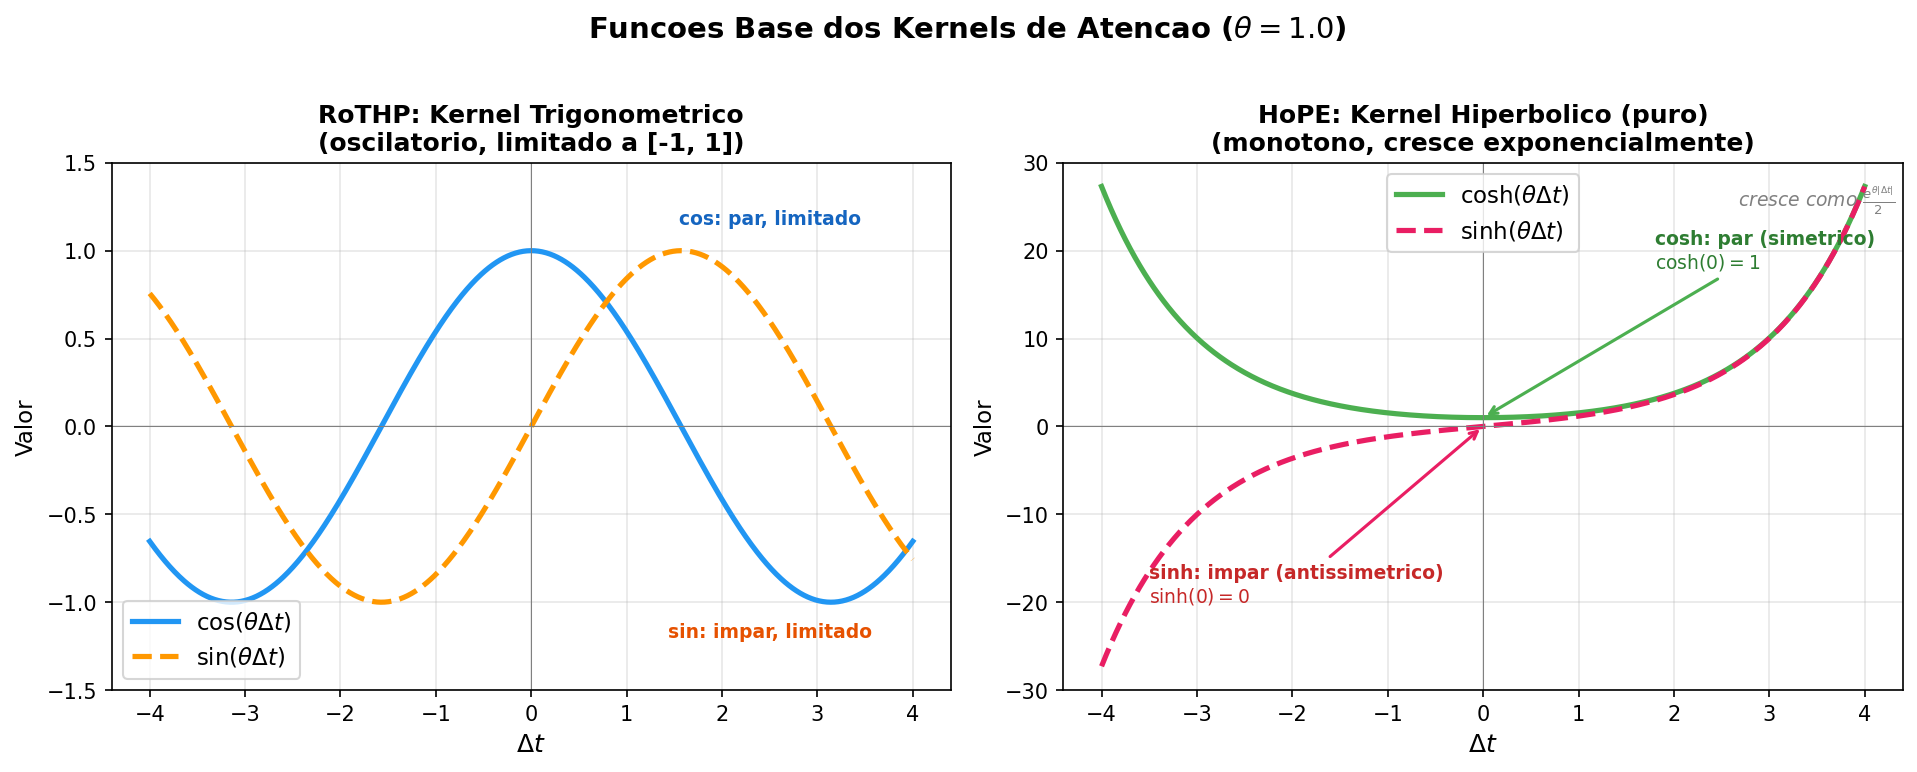

Salvo: ./figuras_dissertacao/fig_trig_vs_hyp.png/.pdf


In [202]:
# ── Figura 8A: Funcoes trigonometricas vs hiperbolicas ────────────────
# Big picture: mostra cos/sin e cosh/sinh no dominio completo (incluindo dt negativos)

dt = np.linspace(-4, 4, 800)
theta = 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Painel esquerdo: cos e sin ──
ax = axes[0]
ax.plot(dt, np.cos(theta * dt), color="#2196F3", linewidth=2.5, label=r"$\cos(\theta \Delta t)$")
ax.plot(dt, np.sin(theta * dt), color="#FF9800", linewidth=2.5, linestyle="--",
        label=r"$\sin(\theta \Delta t)$")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlabel(r"$\Delta t$", fontsize=12)
ax.set_ylabel("Valor", fontsize=11)
ax.set_title("RoTHP: Kernel Trigonometrico\n(oscilatorio, limitado a [-1, 1])", fontweight="bold")
ax.legend(fontsize=11, loc="lower left")
ax.set_ylim(-1.5, 1.5)
ax.grid(True, alpha=0.3)
ax.annotate("cos: par, limitado", xy=(2.5, 1.15), fontsize=9, color="#1565C0",
            ha="center", fontweight="bold")
ax.annotate("sin: impar, limitado", xy=(2.5, -1.2), fontsize=9, color="#E65100",
            ha="center", fontweight="bold")

# ── Painel direito: cosh e sinh (big picture com dt negativo) ──
ax = axes[1]
cosh_vals = np.cosh(theta * dt)
sinh_vals = np.sinh(theta * dt)

ax.plot(dt, cosh_vals, color="#4CAF50", linewidth=2.5, label=r"$\cosh(\theta \Delta t)$")
ax.plot(dt, sinh_vals, color="#E91E63", linewidth=2.5, linestyle="--",
        label=r"$\sinh(\theta \Delta t)$")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlabel(r"$\Delta t$", fontsize=12)
ax.set_ylabel("Valor", fontsize=11)
ax.set_title("HoPE: Kernel Hiperbolico (puro)\n(monotono, cresce exponencialmente)", fontweight="bold")
ax.legend(fontsize=11, loc="upper center")
ax.set_ylim(-30, 30)
ax.grid(True, alpha=0.3)

# Anotacoes mostrando simetria/antissimetria
ax.annotate("cosh: par (simetrico)\n" + r"$\cosh(0) = 1$",
            xy=(0, 1), xytext=(1.8, 18),
            fontsize=9, color="#2E7D32", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#4CAF50", lw=1.5))
ax.annotate("sinh: impar (antissimetrico)\n" + r"$\sinh(0) = 0$",
            xy=(0, 0), xytext=(-3.5, -20),
            fontsize=9, color="#C62828", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#E91E63", lw=1.5))
ax.annotate(r"cresce como $\frac{e^{\theta|\Delta t|}}{2}$",
            xy=(3.5, 25), fontsize=9, color="gray", ha="center", style="italic")

fig.suptitle(r"Funcoes Base dos Kernels de Atencao ($\theta = 1.0$)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_trig_vs_hyp.png"), dpi=300)
fig.savefig(os.path.join(FIG_DIR, "fig_trig_vs_hyp.pdf"))
plt.show()
print(f"Salvo: {FIG_DIR}/fig_trig_vs_hyp.png/.pdf")

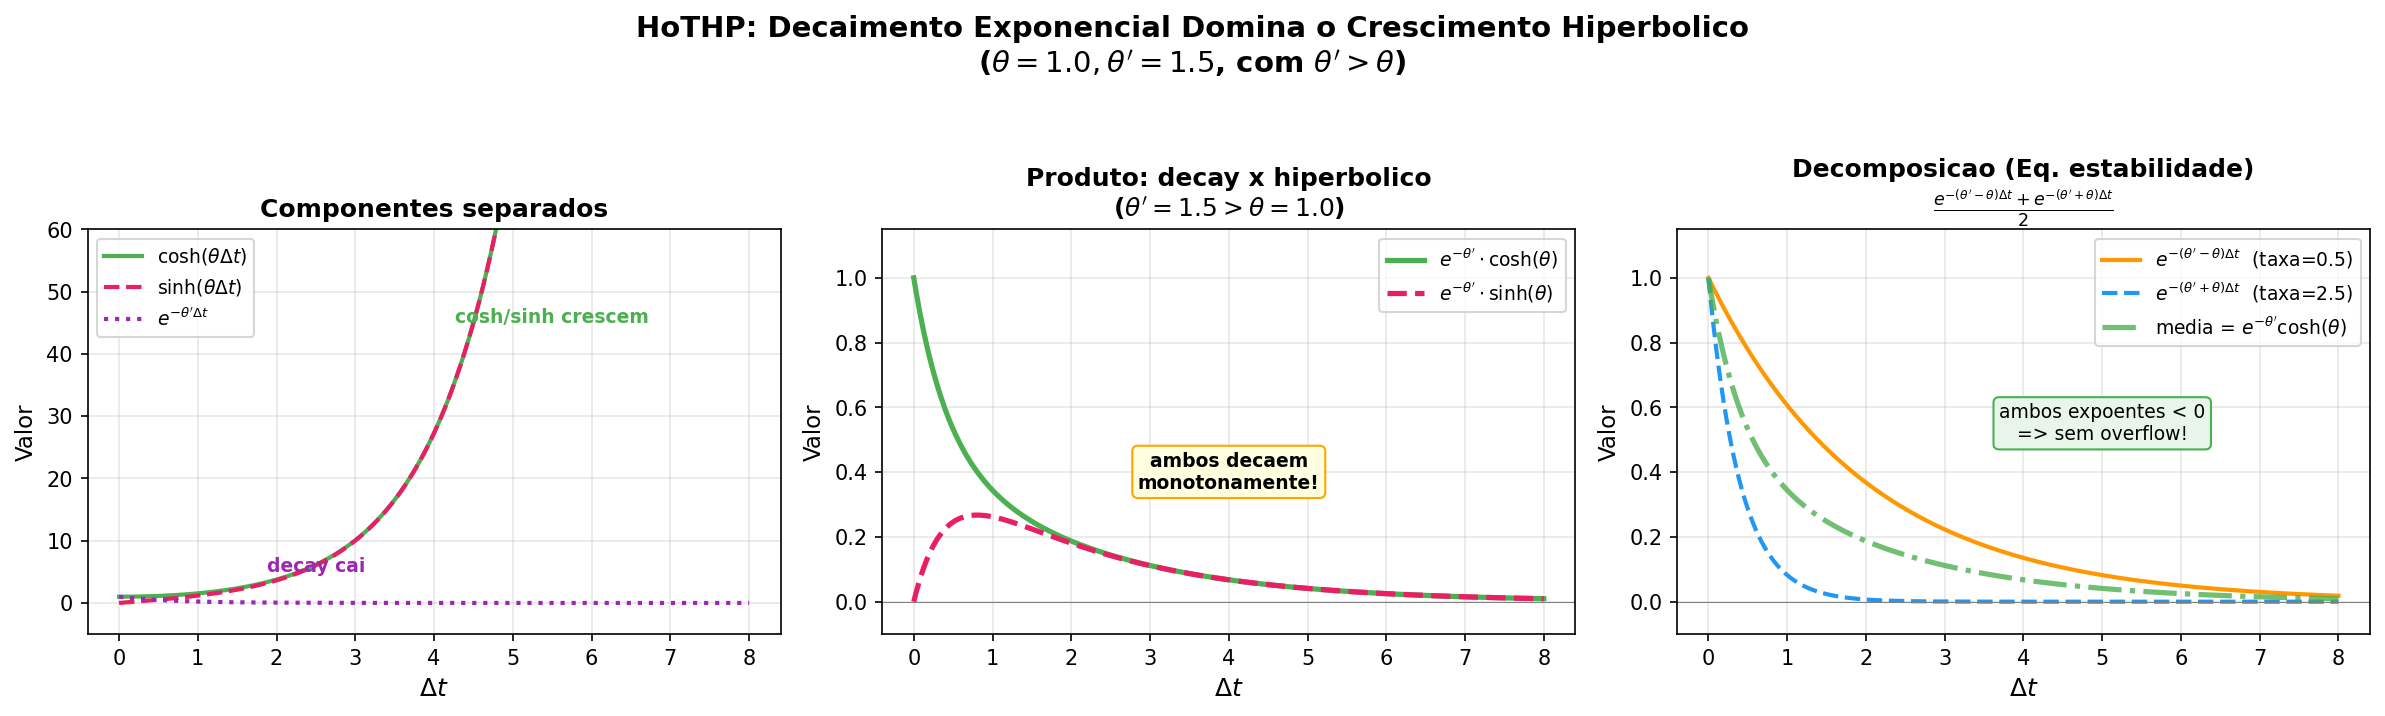

Salvo: ./figuras_dissertacao/fig_decay_hiperbolico.png/.pdf


In [200]:
# ── Figura 8B: Efeito do decaimento exponencial sobre cosh/sinh ──────
# Mostra: cosh/sinh puros (crescem), decay puro (cai), e os produtos (decaem monotonamente).

dt = np.linspace(0, 8, 500)
theta = 1.0
theta_prime = 1.5  # theta' > theta, garante decaimento

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── Painel 1: cosh e sinh puros vs decay puro ──
ax = axes[0]
ax.plot(dt, np.cosh(theta * dt), color="#4CAF50", linewidth=2,
        label=r"$\cosh(\theta \Delta t)$")
ax.plot(dt, np.sinh(theta * dt), color="#E91E63", linewidth=2, linestyle="--",
        label=r"$\sinh(\theta \Delta t)$")
ax.plot(dt, np.exp(-theta_prime * dt), color="#9C27B0", linewidth=2, linestyle=":",
        label=r"$e^{-\theta' \Delta t}$")
ax.set_xlabel(r"$\Delta t$", fontsize=12)
ax.set_ylabel("Valor", fontsize=11)
ax.set_title("Componentes separados", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(-5, 60)
ax.grid(True, alpha=0.3)
ax.annotate("cosh/sinh crescem", xy=(5.5, 45), fontsize=9, color="#4CAF50",
            ha="center", fontweight="bold")
ax.annotate("decay cai", xy=(2.5, 5), fontsize=9, color="#9C27B0",
            ha="center", fontweight="bold")

# ── Painel 2: produtos e^{-theta' dt} * cosh e * sinh ──
ax = axes[1]
stable_cosh = 0.5 * (np.exp(-(theta_prime - theta) * dt) + np.exp(-(theta_prime + theta) * dt))
stable_sinh = 0.5 * (np.exp(-(theta_prime - theta) * dt) - np.exp(-(theta_prime + theta) * dt))

ax.plot(dt, stable_cosh, color="#4CAF50", linewidth=2.5,
        label=r"$e^{-\theta'} \cdot \cosh(\theta)$")
ax.plot(dt, stable_sinh, color="#E91E63", linewidth=2.5, linestyle="--",
        label=r"$e^{-\theta'} \cdot \sinh(\theta)$")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_xlabel(r"$\Delta t$", fontsize=12)
ax.set_ylabel("Valor", fontsize=11)
ax.set_title("Produto: decay x hiperbolico\n" + r"($\theta'=1.5 > \theta=1.0$)",
             fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.set_ylim(-0.1, 1.15)
ax.grid(True, alpha=0.3)
ax.annotate("ambos decaem\nmonotonamente!", xy=(4, 0.35), fontsize=9, color="black",
            ha="center", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="orange"))

# ── Painel 3: decomposicao em exponenciais puras ──
ax = axes[2]
exp_slow = np.exp(-(theta_prime - theta) * dt)
exp_fast = np.exp(-(theta_prime + theta) * dt)

ax.plot(dt, exp_slow, color="#FF9800", linewidth=2,
        label=r"$e^{-(\theta'-\theta)\Delta t}$" + f"  (taxa={theta_prime-theta:.1f})")
ax.plot(dt, exp_fast, color="#2196F3", linewidth=2, linestyle="--",
        label=r"$e^{-(\theta'+\theta)\Delta t}$" + f"  (taxa={theta_prime+theta:.1f})")
ax.plot(dt, stable_cosh, color="#4CAF50", linewidth=2.5, linestyle="-.",
        label=r"media = $e^{-\theta'}\cosh(\theta)$", alpha=0.8)
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_xlabel(r"$\Delta t$", fontsize=12)
ax.set_ylabel("Valor", fontsize=11)
ax.set_title("Decomposicao (Eq. estabilidade)\n"
             + r"$\frac{e^{-(\theta'-\theta)\Delta t} + e^{-(\theta'+\theta)\Delta t}}{2}$",
             fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(-0.1, 1.15)
ax.grid(True, alpha=0.3)
ax.annotate("ambos expoentes < 0\n=> sem overflow!",
            xy=(5, 0.5), fontsize=9, color="black", ha="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#E8F5E9", edgecolor="#4CAF50"))

fig.suptitle("HoTHP: Decaimento Exponencial Domina o Crescimento Hiperbolico\n"
             + r"($\theta = 1.0, \theta' = 1.5$, com $\theta' > \theta$)",
             fontsize=14, fontweight="bold", y=1.05)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_decay_hiperbolico.png"), dpi=300)
fig.savefig(os.path.join(FIG_DIR, "fig_decay_hiperbolico.pdf"))
plt.show()
print(f"Salvo: {FIG_DIR}/fig_decay_hiperbolico.png/.pdf")

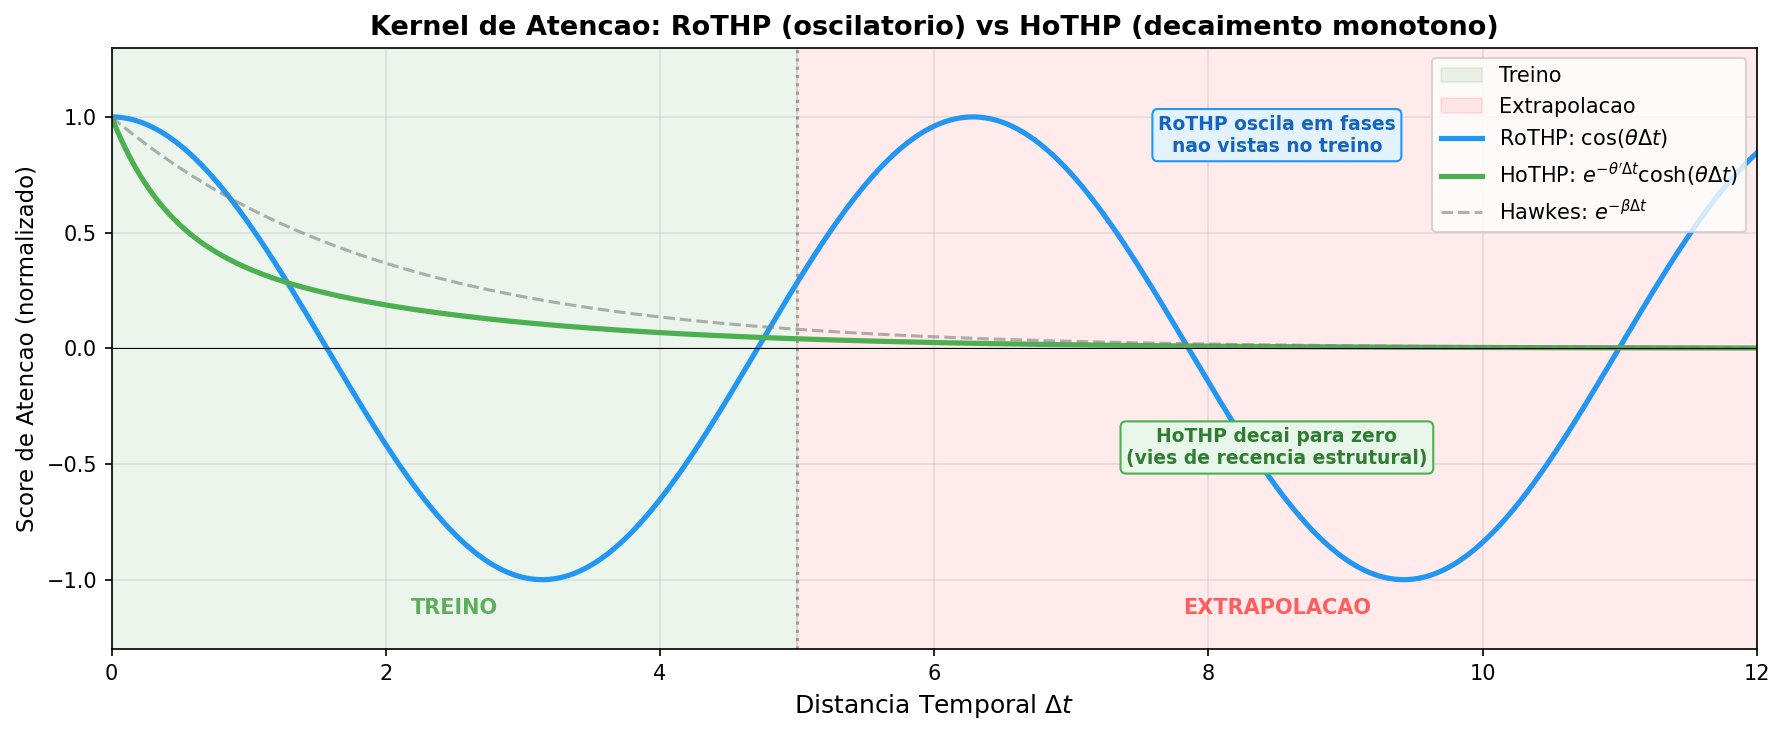

Salvo: ./figuras_dissertacao/fig_kernel_rothp_vs_hothp.{png,pdf}


In [201]:
# ── Figura 8C: Score de atencao — RoTHP vs HoTHP ─────────────────────
# Compara o kernel de atencao dos dois modelos em funcao de Delta_t,
# mostrando o que acontece na regiao de extrapolacao.

dt = np.linspace(0, 12, 1000)
theta = 1.0
theta_prime = 1.5

# Zona de treino vs extrapolacao
train_limit = 5.0  # Delta_t maximo visto no treino

# Kernel RoTHP: cos(theta * dt) — componente dominante do score (parte real da rotacao)
kernel_rothp = np.cos(theta * dt)

# Kernel HoTHP: e^{-theta' dt} * cosh(theta dt) — componente cosh do score
kernel_hothp = 0.5 * (np.exp(-(theta_prime - theta) * dt) + np.exp(-(theta_prime + theta) * dt))

# Referencia: kernel de Hawkes classico (alpha * e^{-beta dt})
kernel_hawkes = np.exp(-0.5 * dt)

fig, ax = plt.subplots(figsize=(12, 5))

# Fundo: zona de treino vs extrapolacao
ax.axvspan(0, train_limit, alpha=0.08, color="green", label="Treino")
ax.axvspan(train_limit, 12, alpha=0.08, color="red", label="Extrapolacao")
ax.axvline(train_limit, color="gray", linewidth=1.5, linestyle=":", alpha=0.7)

# Kernels
ax.plot(dt, kernel_rothp, color="#2196F3", linewidth=2.5, label="RoTHP: " + r"$\cos(\theta \Delta t)$")
ax.plot(dt, kernel_hothp, color="#4CAF50", linewidth=2.5,
        label="HoTHP: " + r"$e^{-\theta' \Delta t} \cosh(\theta \Delta t)$")
ax.plot(dt, kernel_hawkes, color="gray", linewidth=1.5, linestyle="--", alpha=0.6,
        label=r"Hawkes: $e^{-\beta \Delta t}$")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel(r"Distancia Temporal $\Delta t$", fontsize=12)
ax.set_ylabel("Score de Atencao (normalizado)", fontsize=11)
ax.set_title("Kernel de Atencao: RoTHP (oscilatorio) vs HoTHP (decaimento monotono)",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=10, loc="upper right")
ax.set_ylim(-1.3, 1.3)
ax.set_xlim(0, 12)
ax.grid(True, alpha=0.3)

# Anotacoes
ax.annotate("RoTHP oscila em fases\nnao vistas no treino",
            xy=(8.5, 0.85), fontsize=9, color="#1565C0", ha="center",
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#E3F2FD", edgecolor="#2196F3"))
ax.annotate("HoTHP decai para zero\n(vies de recencia estrutural)",
            xy=(8.5, -0.5), fontsize=9, color="#2E7D32", ha="center",
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#E8F5E9", edgecolor="#4CAF50"))
ax.text(train_limit / 2, -1.15, "TREINO", ha="center", fontsize=10, fontweight="bold",
        color="green", alpha=0.6)
ax.text(train_limit + (12 - train_limit) / 2, -1.15, "EXTRAPOLACAO", ha="center",
        fontsize=10, fontweight="bold", color="red", alpha=0.6)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_kernel_rothp_vs_hothp.png"), dpi=300)
fig.savefig(os.path.join(FIG_DIR, "fig_kernel_rothp_vs_hothp.pdf"))
plt.show()
print(f"Salvo: {FIG_DIR}/fig_kernel_rothp_vs_hothp.{{png,pdf}}")